In [2]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
plot_root = repo_root.parent.parent / 'Plots' / "CBOS"
lis_plot_root = repo_root.parent.parent / 'Plots' / 'LIS'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

# import local toolkit (try normal import first, fall back to loading from file)
try:
    import inequality_analyzers as inqA
    import local_utility_functions as luf
except Exception:
	import importlib.util
	toolkit_path = repo_root / 'Code' / 'tools' / 'inequality_analyzers.py'
	if toolkit_path.exists():
		spec = importlib.util.spec_from_file_location("inequality_analyzers", str(toolkit_path))
		stk = importlib.util.module_from_spec(spec)
		spec.loader.exec_module(stk)
	else:
		raise

In [3]:
# Load final data
df = pd.read_csv(data_root / 'CBOS_data_final_with_income.csv')

# Load inflation data
inflation_data = pd.read_csv(data_root.parent / 'Auxiliary data' / 'inflation_data_cleaned.csv', index_col=0, parse_dates=True)

# Sort the inflation data by index (date)
inflation_data = inflation_data.sort_index()
org_inflation_data = inflation_data.copy()

# We assmue Jan 1990 to be the base month with inflation index 100
# Every other month's index is relative to previous months
inflation_data.loc[pd.Timestamp('1990-01-01')] = 100.0

# Remove older months if any
inflation_data = inflation_data[inflation_data.index >= pd.Timestamp('1990-01-01')]


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_72469/947049682.py:2: DtypeWarning: Columns (14,15,20,21,22,38,40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_root / 'CBOS_data_final_with_income.csv')


In [4]:
### Deflate the income_hh variable using the inflation data

# First, create a survey_date column in df
df['survey_date'] = pd.to_datetime(df['survey year'].astype(str) + '-' + df['survey month'].astype(str) + '-01', format='%Y-%m-%d')

# Reference date: first survey date (1990-01-01)
ref_date = pd.Timestamp('1990-01-01')

# Create income series indexed by survey_date
# Since we have multiple observations per date, we need to get unique dates first
# then map deflation factors back to the dataframe
unique_dates = sorted(df['survey_date'].unique())
dummy_income = pd.Series(100.0, index=pd.to_datetime(unique_dates), name='dummy')

# Use deflate_income function with exact survey dates
# The inflation_index represents month-to-month CPI ratios (100 = no change, 110 = 10% increase)
deflated_dummy = luf.deflate_income(
    income_series=dummy_income,
    cpi_series=org_inflation_data['inflation_index'],
    ref_date=ref_date,
    income_freq='M',
    cpi_is_rate=True,  # inflation_index contains month-to-month ratios
    use_exact_dates=True  # use exact survey dates, not month-end dates
)

# Compute deflation factors from the dummy results
deflation_factors = (deflated_dummy / 100.0).to_dict()

# Apply deflation factors to all rows
df['income_hh_deflated'] = df.apply(
    lambda row: row['income_hh'] * deflation_factors[row['survey_date']] if pd.notna(row['income_hh']) else np.nan,
    axis=1
)

In [5]:
inflation_data

,inflation_index
1990-01-01,100.0
1990-02-01,123.8
1990-03-01,104.3
1990-04-01,107.5
1990-05-01,104.6
...,...
2025-08-01,100.0
2025-09-01,100.0
2025-10-01,100.1
2025-11-01,100.1


In [6]:
import matplotlib.pyplot as plt
# Set parmeters for plots
plt.rcParams.update({
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300
})

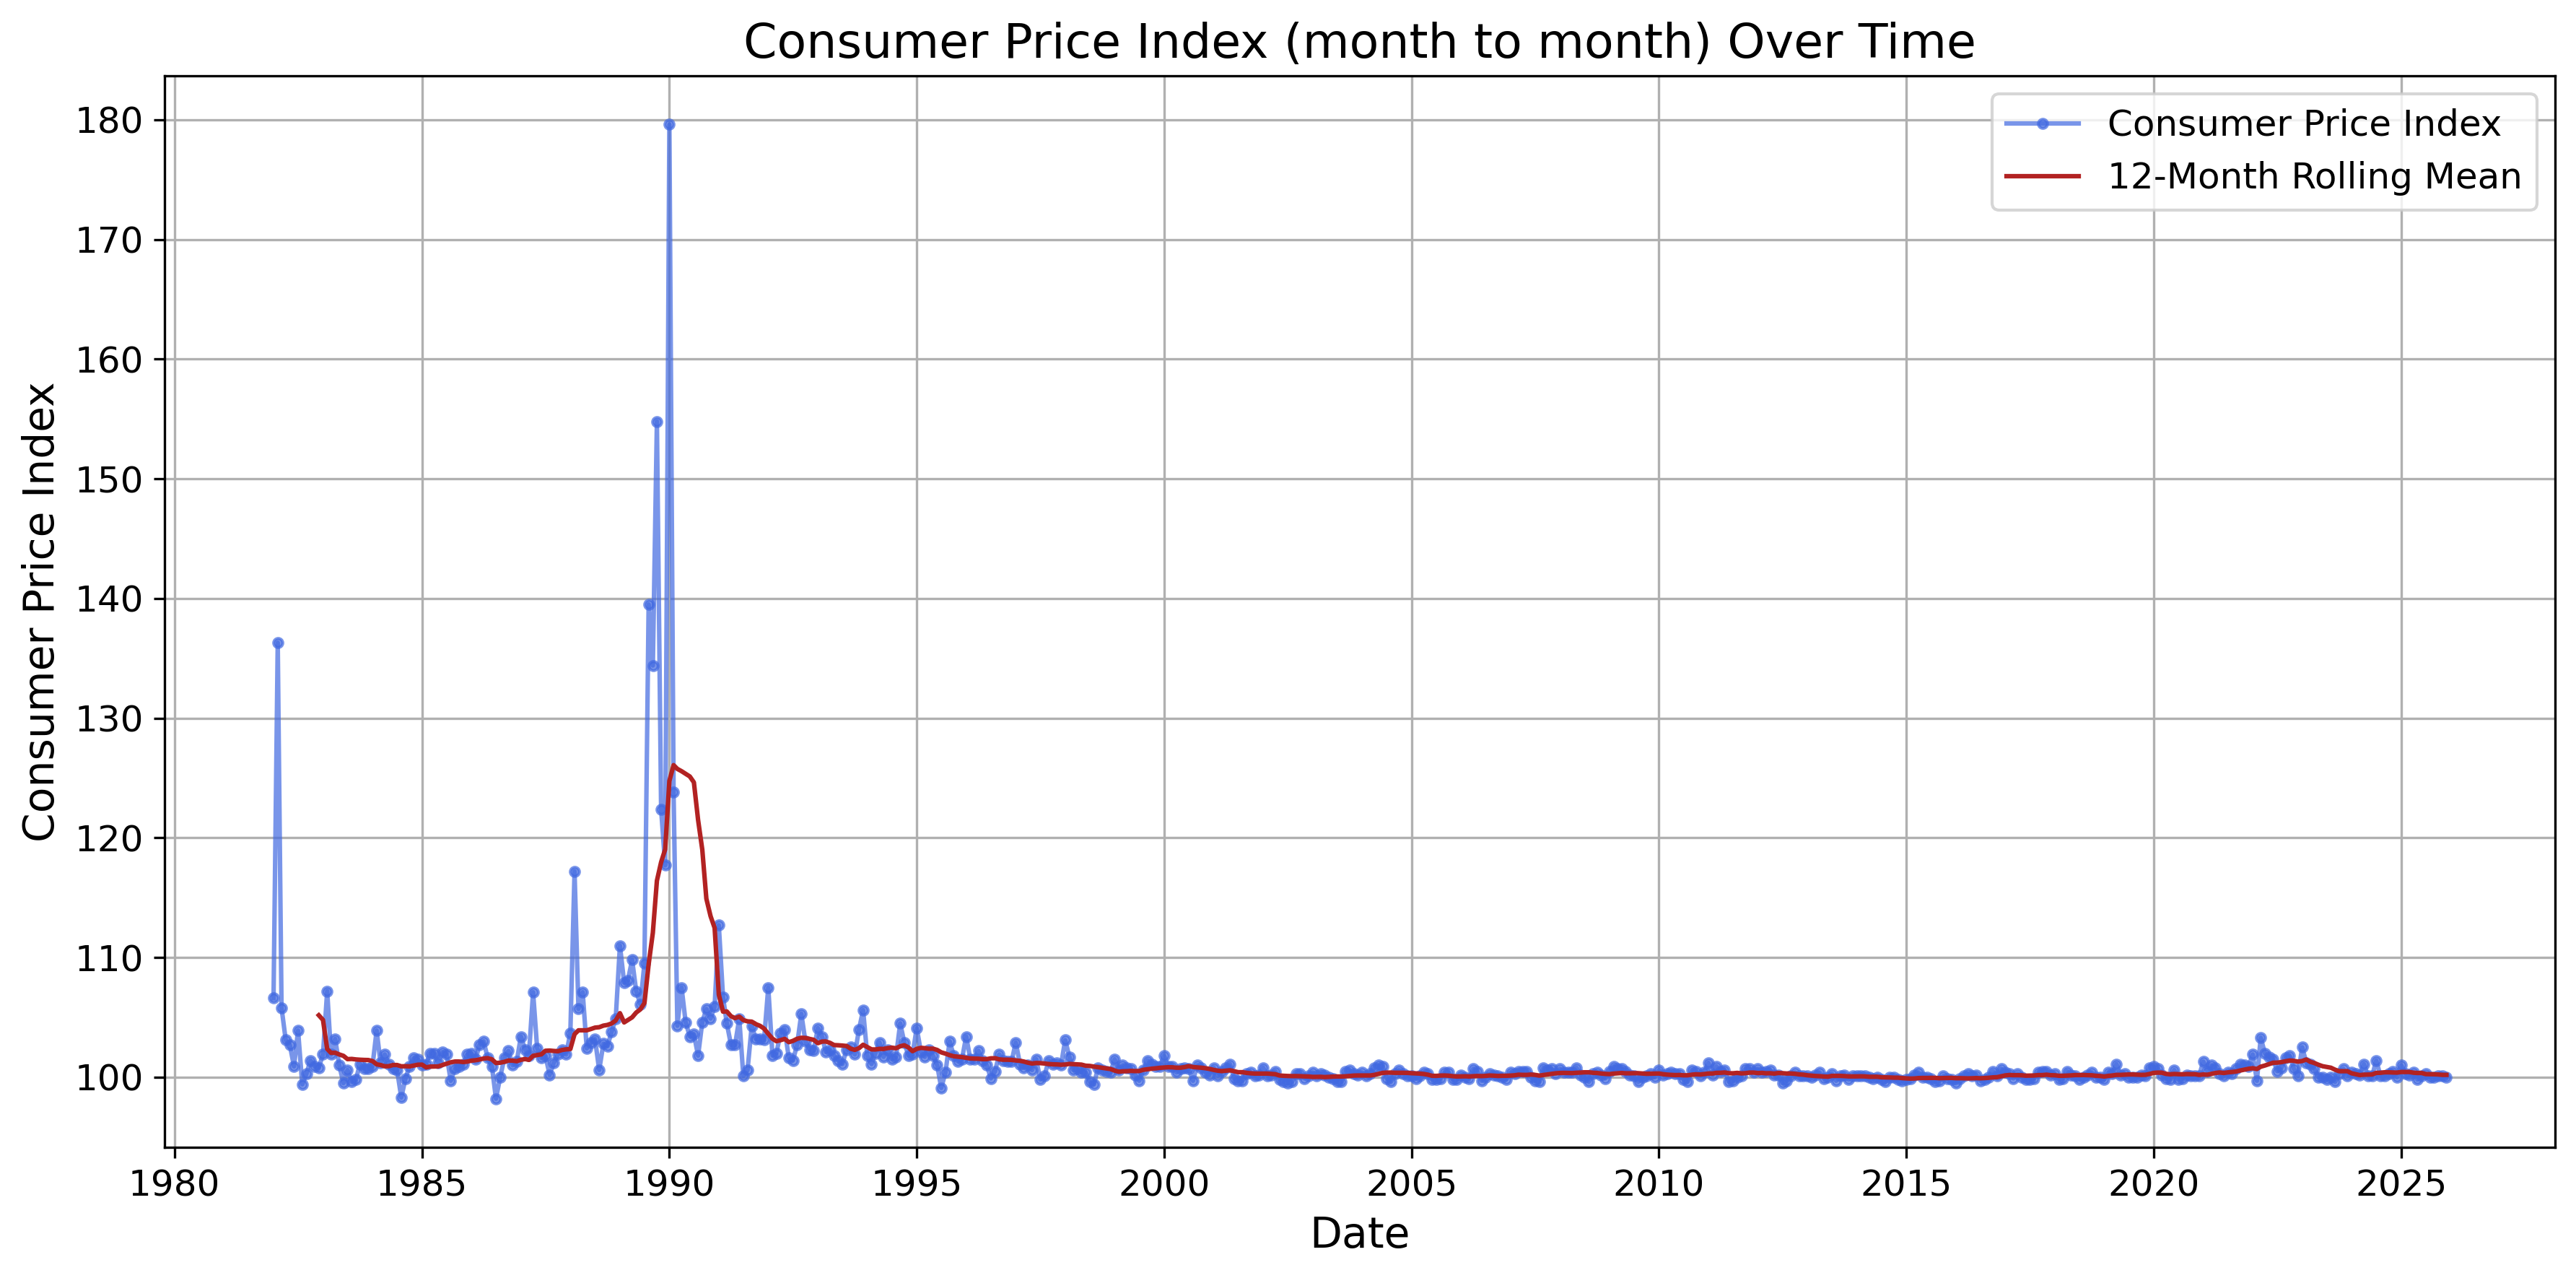

In [7]:
# Plot the inflation data
plt.figure(figsize=(12,6))
plt.plot(org_inflation_data.index, org_inflation_data['inflation_index'], label='Consumer Price Index', color='royalblue', alpha=0.7, marker='.')
roll_mean = org_inflation_data['inflation_index'].rolling(window=12).mean()
plt.plot(org_inflation_data.index, roll_mean, label='12-Month Rolling Mean', color='firebrick')
plt.title('Consumer Price Index (month to month) Over Time')
plt.xlabel('Date')
plt.ylabel('Consumer Price Index')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_1_inflation.png', dpi =300)
plt.show()


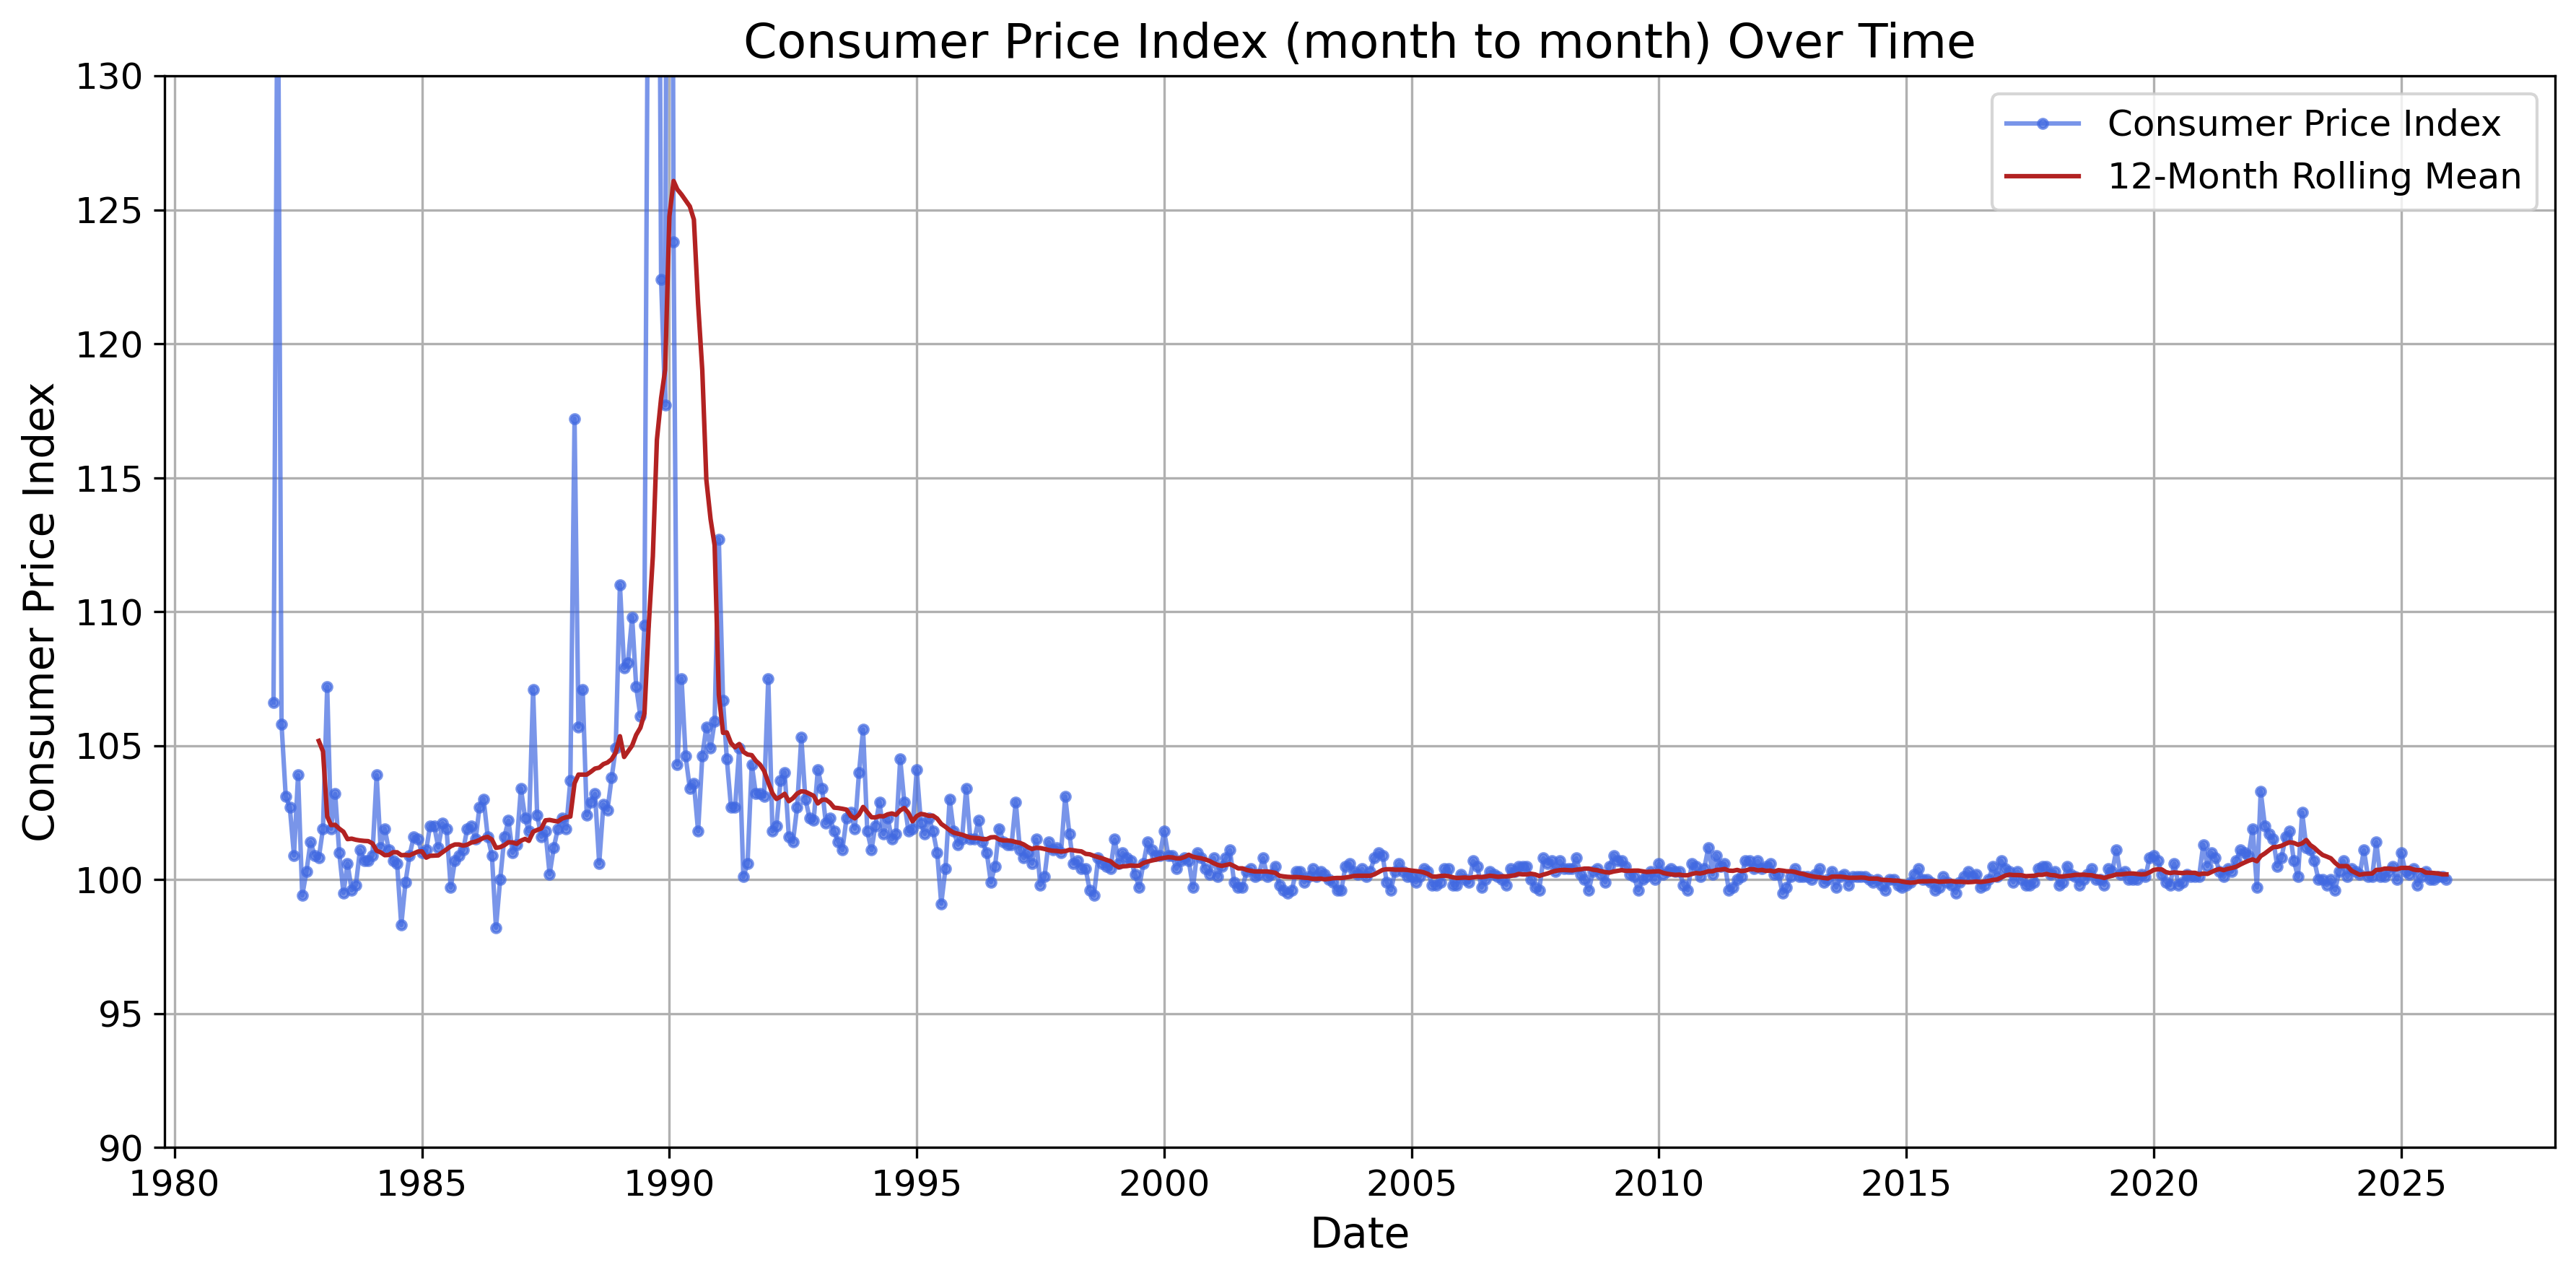

In [8]:
# Plot the inflation data
plt.figure(figsize=(12,6))
plt.plot(org_inflation_data.index, org_inflation_data['inflation_index'], label='Consumer Price Index', color='royalblue', alpha=0.7, marker='.')
roll_mean = org_inflation_data['inflation_index'].rolling(window=12).mean()
plt.plot(org_inflation_data.index, roll_mean, label='12-Month Rolling Mean', color='firebrick')
plt.title('Consumer Price Index (month to month) Over Time')
plt.xlabel('Date')
plt.ylabel('Consumer Price Index')
plt.ylim(90, 130)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_2_inflation.png', dpi =300)
plt.show()


In [9]:
df[['survey_date', 'income_hh_OLD', 'income_hh_NEW', 'income_hh_deflated']]

,survey_date,income_hh_OLD,income_hh_NEW,income_hh_deflated
0,1990-01-01,380.0,0.0,38.000000
1,1990-01-01,400.0,0.0,40.000000
2,1990-01-01,170.0,0.0,17.000000
3,1990-01-01,375.0,0.0,37.500000
4,1990-01-01,430.0,0.0,43.000000
...,...,...,...,...
358520,2017-12-01,0.0,NaN,NaN
358521,2017-12-01,0.0,1500.0,61.934773
358522,2017-12-01,0.0,900.0,37.160864
358523,2017-12-01,0.0,1500.0,61.934773


In [10]:
IA_defl = inqA.InequalityAnalyzer(df, income_col='income_hh_deflated')
IA = inqA.InequalityAnalyzer(df, income_col='income_hh')

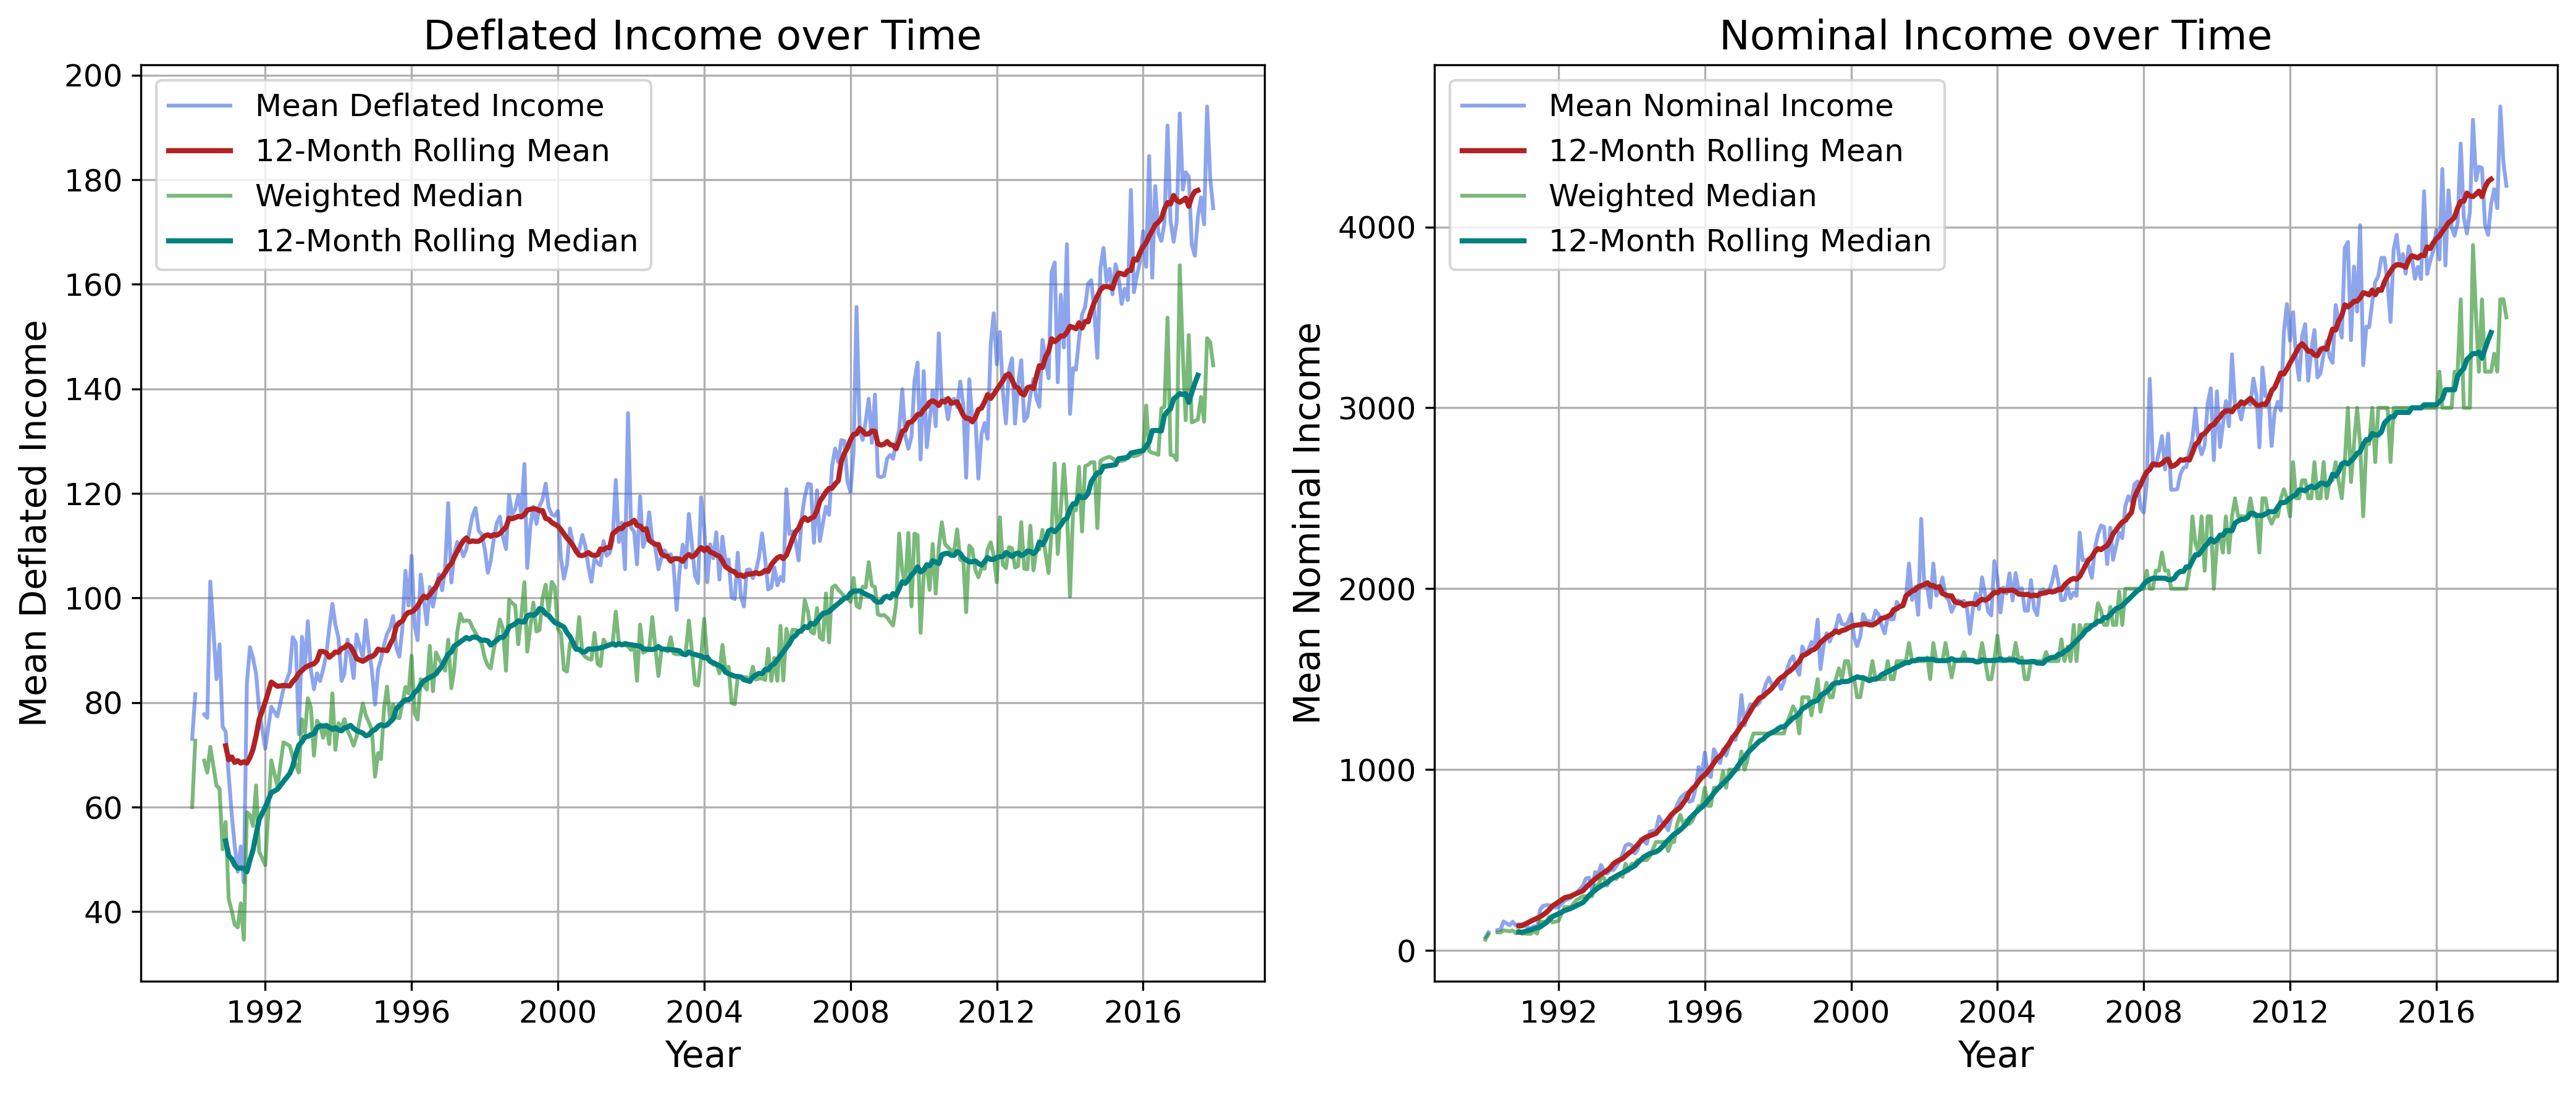

In [11]:
# plot means over time
import matplotlib.pyplot as plt

ts_defl = IA_defl.time_series.weighted_mean_total.values
ts = IA.time_series.weighted_mean_total.values
med_ts_defl = IA_defl.time_series.weighted_median_total.values
med_ts = IA.time_series.weighted_median_total.values

# 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(IA_defl.time_series.index, ts_defl, label='Mean Deflated Income', color='royalblue', alpha=0.6)
roll_mean_defl = pd.Series(ts_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_defl, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[0].plot(IA_defl.time_series.index, med_ts_defl, label='Weighted Median', color='forestgreen', alpha=0.6)
roll_mean_med_defl = pd.Series(med_ts_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_med_defl, label='12-Month Rolling Median', color='teal', linewidth=2)
ax[0].set_title('Deflated Income over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Mean Deflated Income')
ax[1].plot(IA.time_series.index, ts, color='royalblue', alpha=0.6, label='Mean Nominal Income')
roll_mean = pd.Series(ts).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[1].plot(IA.time_series.index, med_ts, label='Weighted Median', color='forestgreen', alpha=0.6)
roll_mean_med = pd.Series(med_ts).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean_med, label='12-Month Rolling Median', color='teal', linewidth=2)
ax[1].set_title('Nominal Income over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Mean Nominal Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_3_income_comparison.png', dpi =300)
plt.show()


In [12]:
# Missing observations in income_hh * household_size per month
total_counts = []
missing_counts = []
for file in df['survey file'].unique():
    temp_df = df[df['survey file'] == file]
    missing_count = (temp_df['income_hh'] * temp_df['household_size']).isna().sum()
    total_count = temp_df.shape[0]
    total_counts.append(total_count)
    missing_counts.append(float(missing_count/total_count)*100)

In [13]:
index = df['survey_date'].unique()
missing_counts_series = pd.Series(missing_counts, index=index)
total_counts_series = pd.Series(total_counts, index=index)

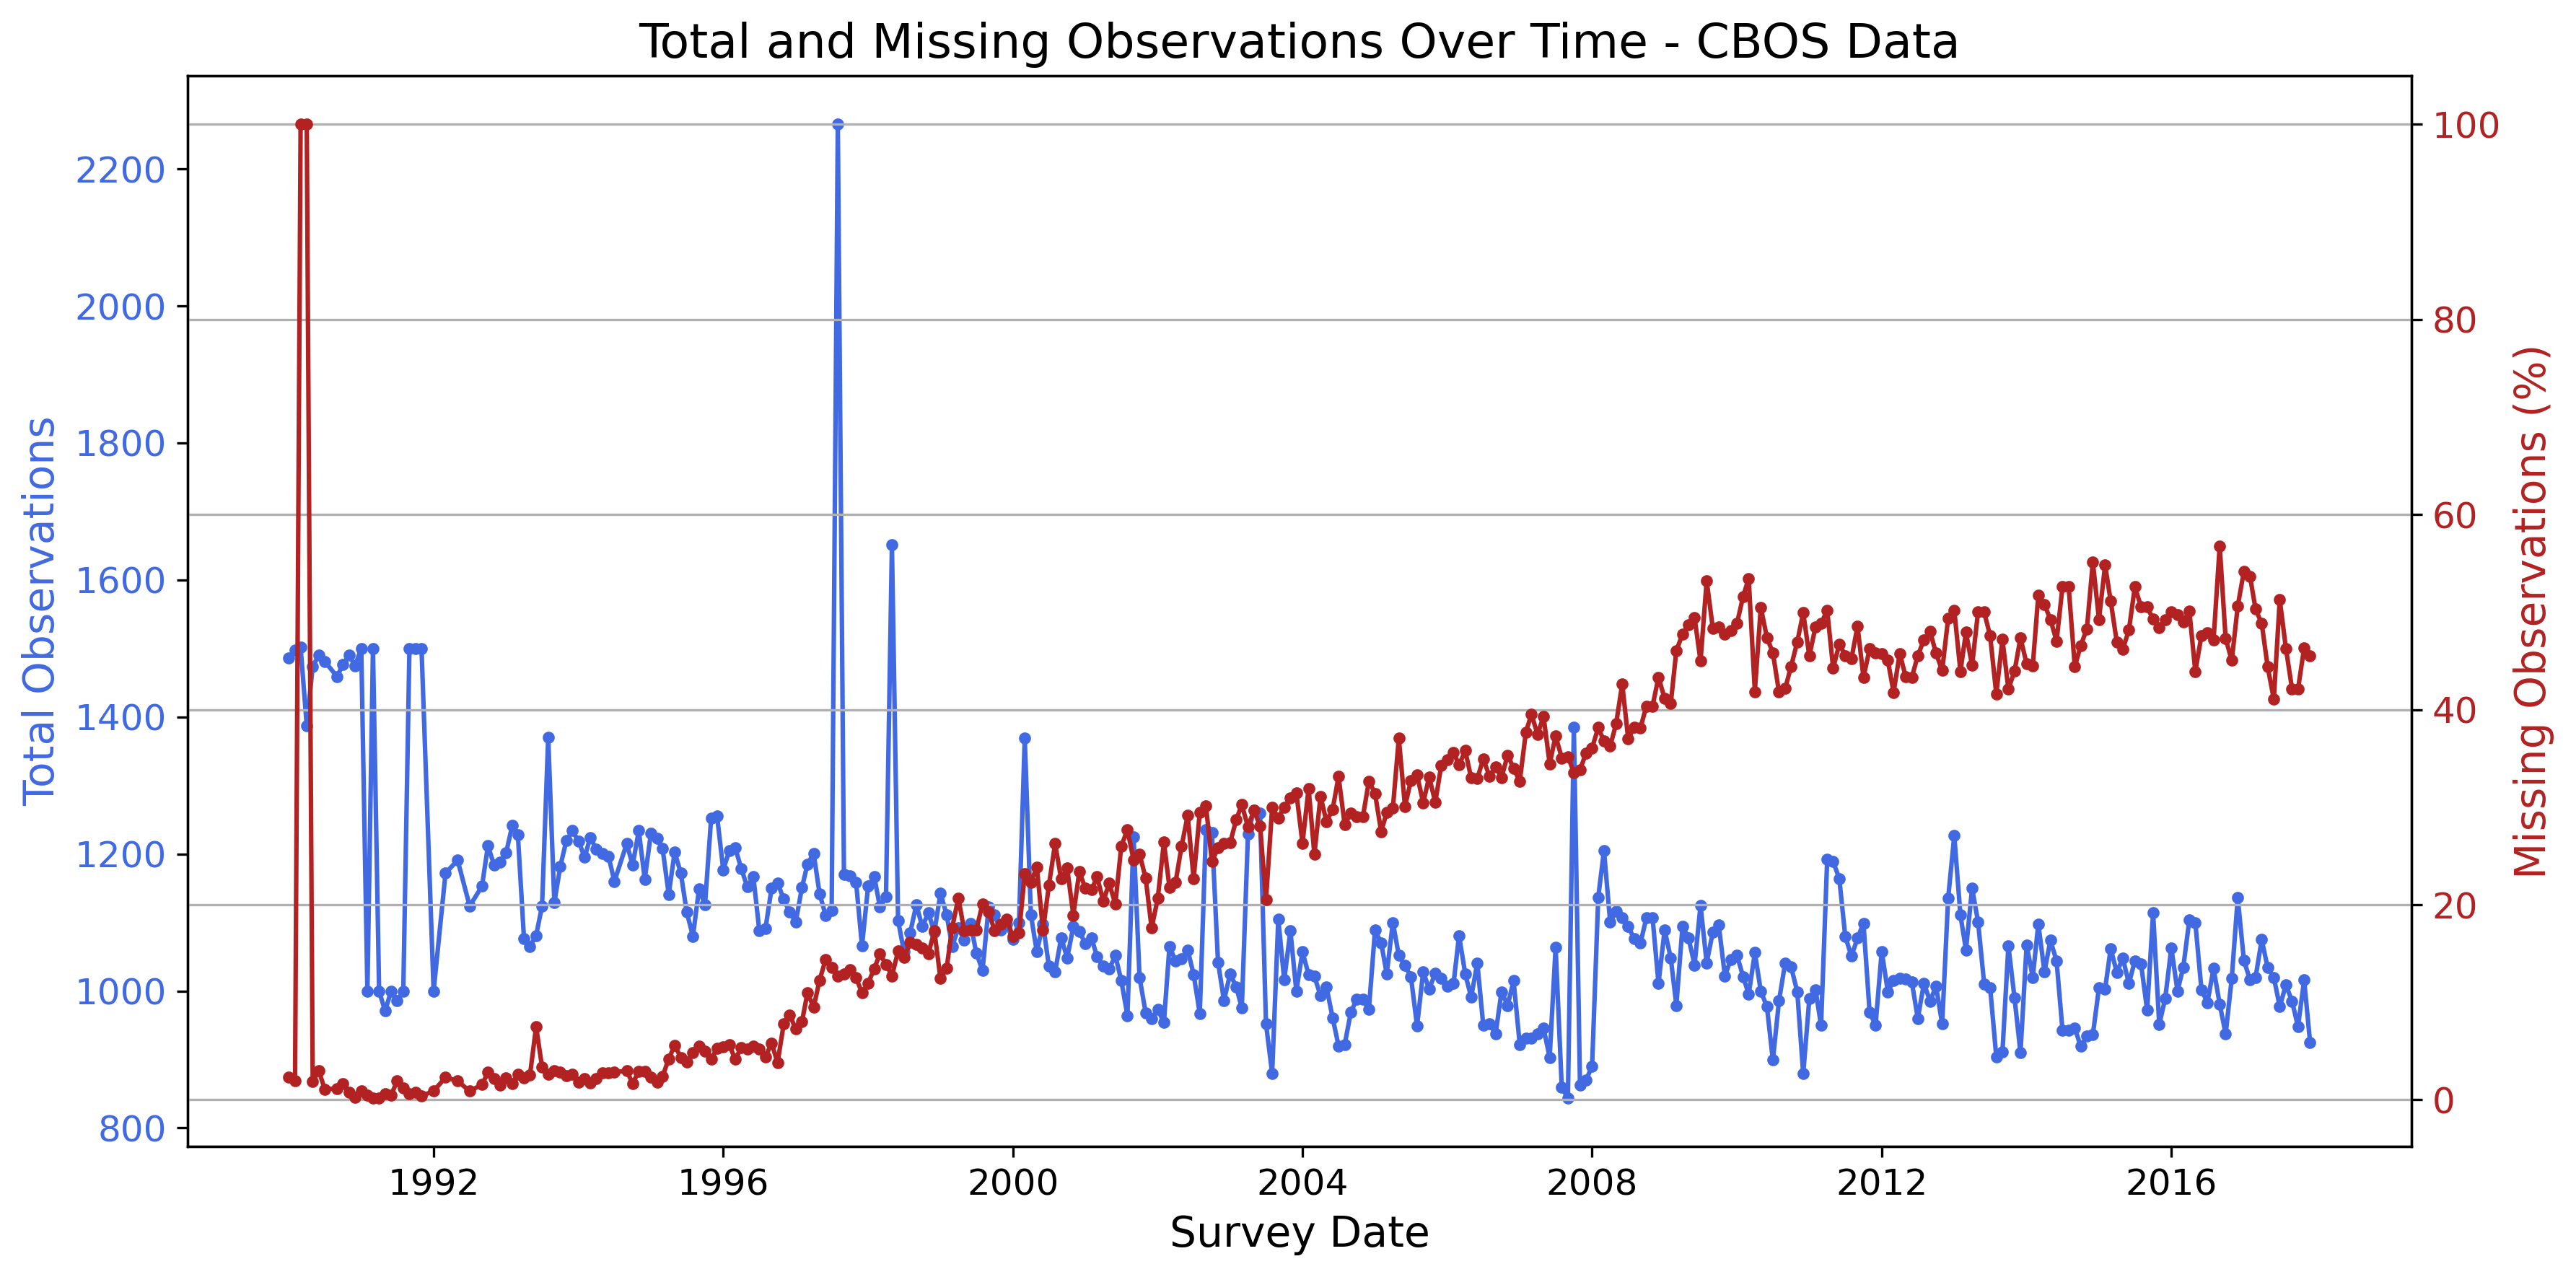

In [14]:
# plot total counts and missing values procent over time with two y-axes
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.set_xlabel('Survey Date')
ax1.set_ylabel('Total Observations', color='royalblue')
ax1.plot(total_counts_series.index, total_counts_series.values, marker='.', color='royalblue', label='Total Observations')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Missing Observations (%)', color='firebrick')  # we already handled the x-label with ax1
ax2.plot(missing_counts_series.index, missing_counts_series.values, marker='.', color='firebrick', label='Missing Observations (%)')
ax2.tick_params(axis='y', labelcolor='firebrick')
plt.title('Total and Missing Observations Over Time - CBOS Data')
plt.grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_4_missing_observations.png', dpi =300)
plt.show()


In [15]:
# Save the df with deflated income_hh
output_file = data_root / 'CBOS_data_final_deflated_income.csv'
df.to_csv(output_file, index=False)

In [16]:
IA.compute_income_groups()
IA_defl.compute_income_groups()
IA.compute_income_shares()
IA_defl.compute_income_shares()

,bottom_50,middle_40,top_10,top_1
date,,,,
1990-01-01,0.269587,0.456666,0.273747,0.080066
1990-02-01,0.278733,0.457104,0.264163,0.071832
1990-03-01,NaN,NaN,NaN,NaN
1990-04-01,NaN,NaN,NaN,NaN
1990-05-01,0.272749,0.486064,0.241187,0.047431
...,...,...,...,...
2017-08-01,0.248513,0.464311,0.287176,0.053187
2017-09-01,0.237437,0.460528,0.302036,0.073789
2017-10-01,0.231450,0.466069,0.302481,0.069759


In [17]:
ts_defl = IA_defl.income_groups
ts = IA.income_groups
b50_defl = ts_defl['bottom_50']
m40_defl = ts_defl['middle_40']
t10_defl = ts_defl['top_10']
t1_defl = ts_defl['top_1']
b50 = ts['bottom_50']
m40 = ts['middle_40']
t10 = ts['top_10']
t1 = ts['top_1']
display(ts_defl)
display(ts)

,bottom_50,middle_40,top_10,top_1
date,,,,
1990-01-01,39.415310,83.459138,198.746575,565.800000
1990-02-01,45.527417,93.200576,215.444595,574.124933
1990-03-01,NaN,NaN,NaN,NaN
1990-04-01,NaN,NaN,NaN,NaN
1990-05-01,42.399385,94.514820,186.947610,355.389506
...,...,...,...,...
2017-08-01,77.287667,211.497542,549.898139,1115.303350
2017-09-01,74.307074,194.401287,559.444859,1272.437391
2017-10-01,80.139337,224.040710,654.384790,1329.787894


,bottom_50,middle_40,top_10,top_1
date,,,,
1990-01-01,39.415310,83.459138,198.746575,565.800000
1990-02-01,56.362943,115.382313,266.720408,710.766667
1990-03-01,NaN,NaN,NaN,NaN
1990-04-01,NaN,NaN,NaN,NaN
1990-05-01,61.560858,137.228720,271.434483,516.000000
...,...,...,...,...
2017-08-01,1842.185450,5041.136685,13107.063328,26583.744504
2017-09-01,1778.226257,4652.174500,13387.952035,30450.419706
2017-10-01,1927.385864,5388.276361,15738.238363,31981.976300


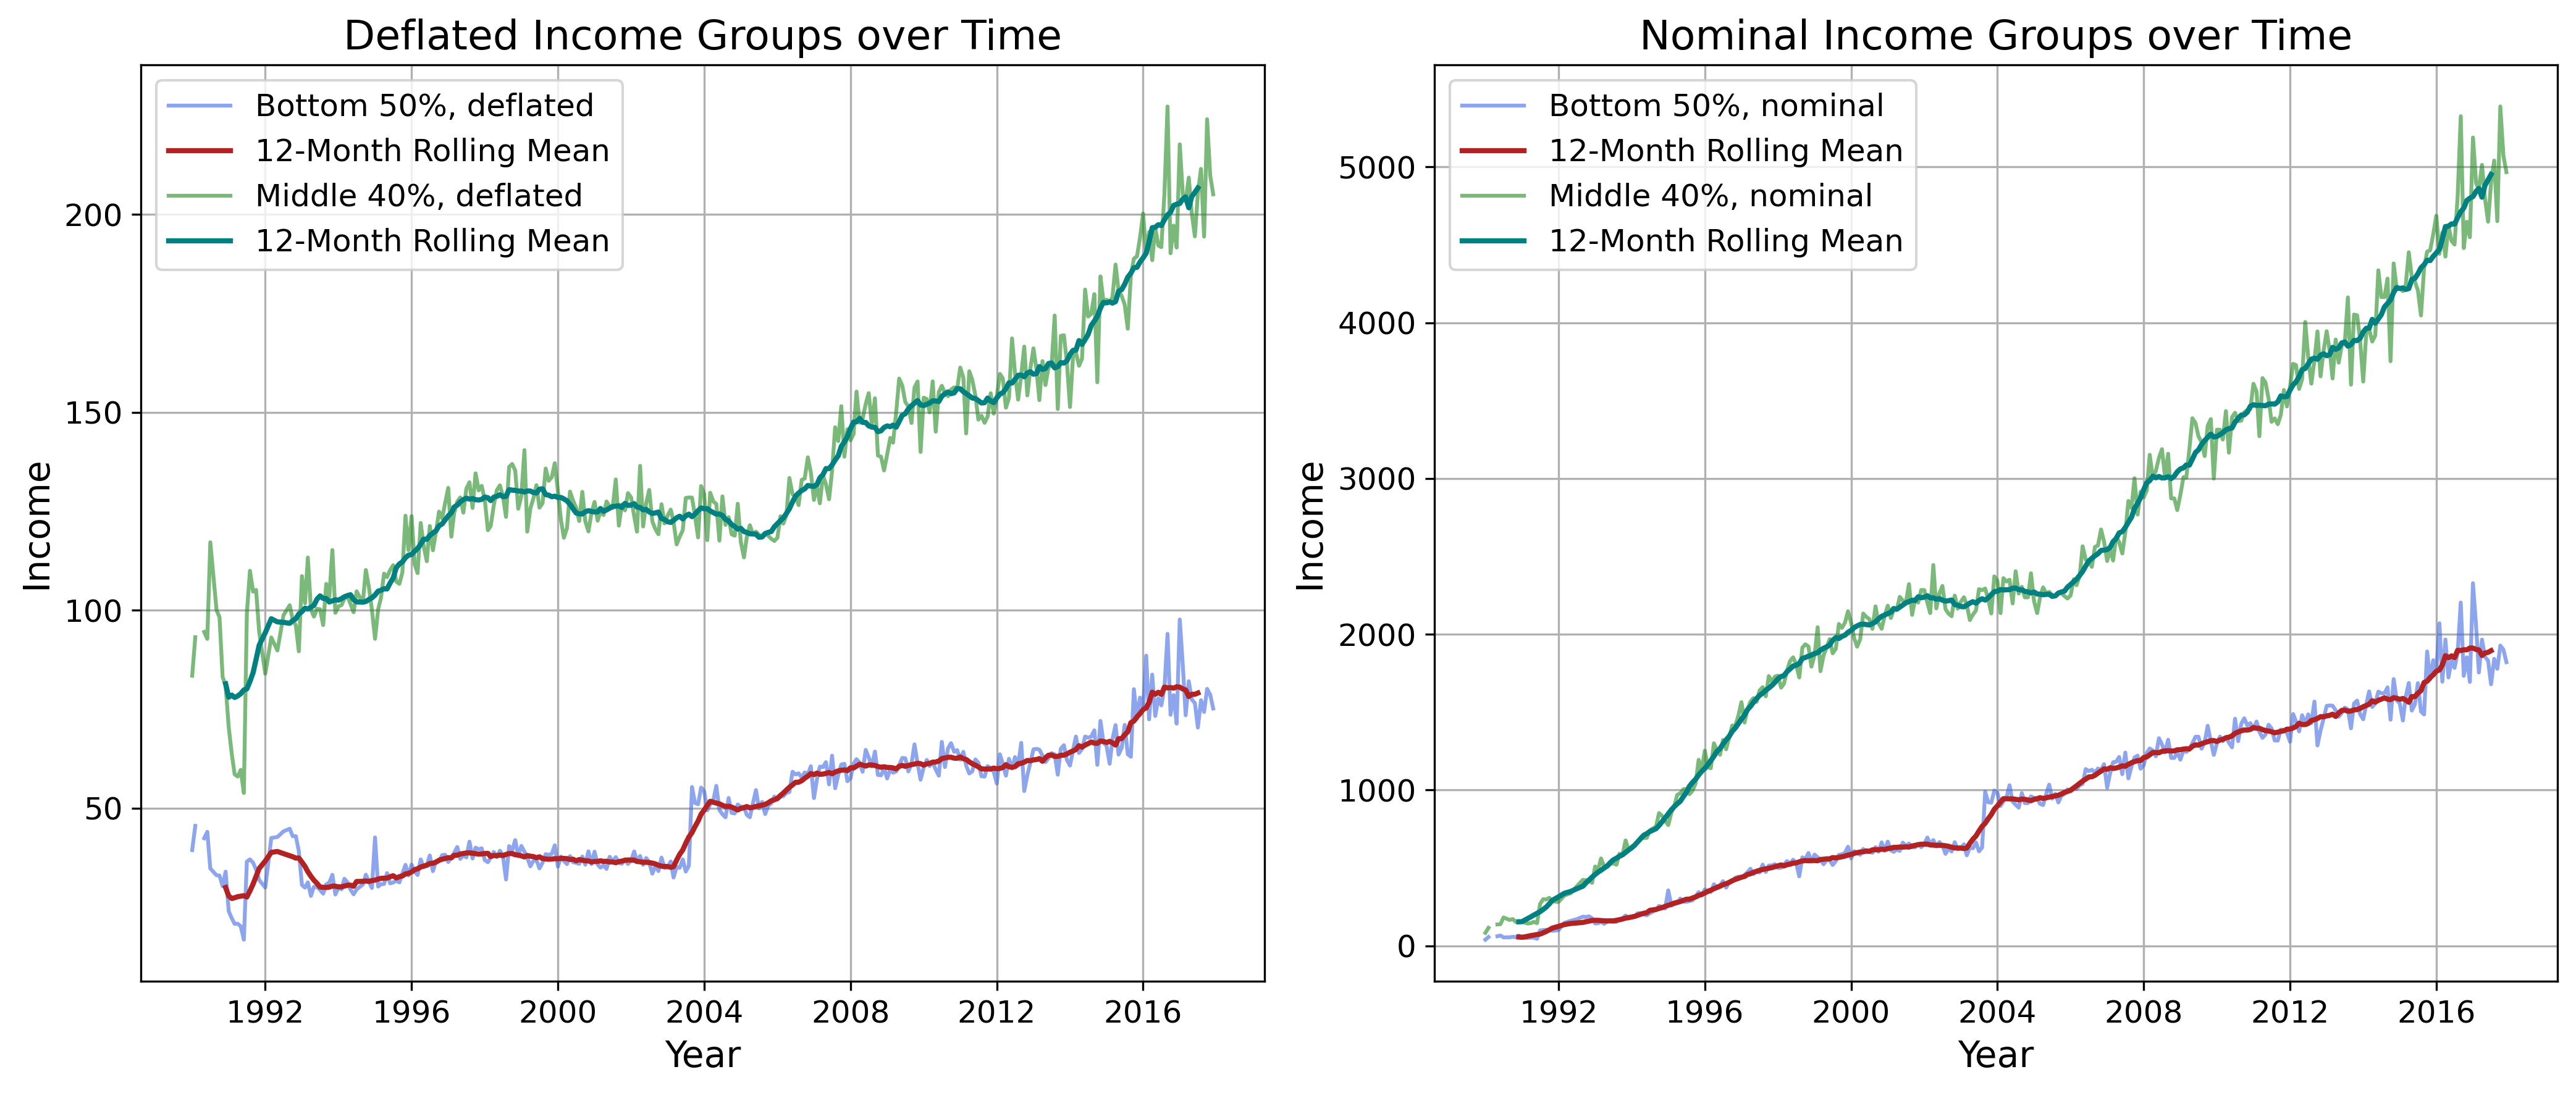

In [18]:

# 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(IA_defl.time_series.index, b50_defl, label='Bottom 50%, deflated', color='royalblue', alpha=0.6)
roll_mean_defl = pd.Series(b50_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_defl, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[0].plot(IA_defl.time_series.index, m40_defl, label='Middle 40%, deflated', color='forestgreen', alpha=0.6)
roll_mean_med_defl = pd.Series(m40_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_med_defl, label='12-Month Rolling Mean', color='teal', linewidth=2)
ax[0].set_title('Deflated Income Groups over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Income')
ax[1].plot(IA.time_series.index, b50, color='royalblue', alpha=0.6, label='Bottom 50%, nominal')
roll_mean = pd.Series(b50).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[1].plot(IA.time_series.index, m40, label='Middle 40%, nominal', color='forestgreen', alpha=0.6)
roll_mean_med = pd.Series(m40).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean_med, label='12-Month Rolling Mean', color='teal', linewidth=2)
ax[1].set_title('Nominal Income Groups over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_5_income_groups_comparison.png', dpi =300)
plt.show()

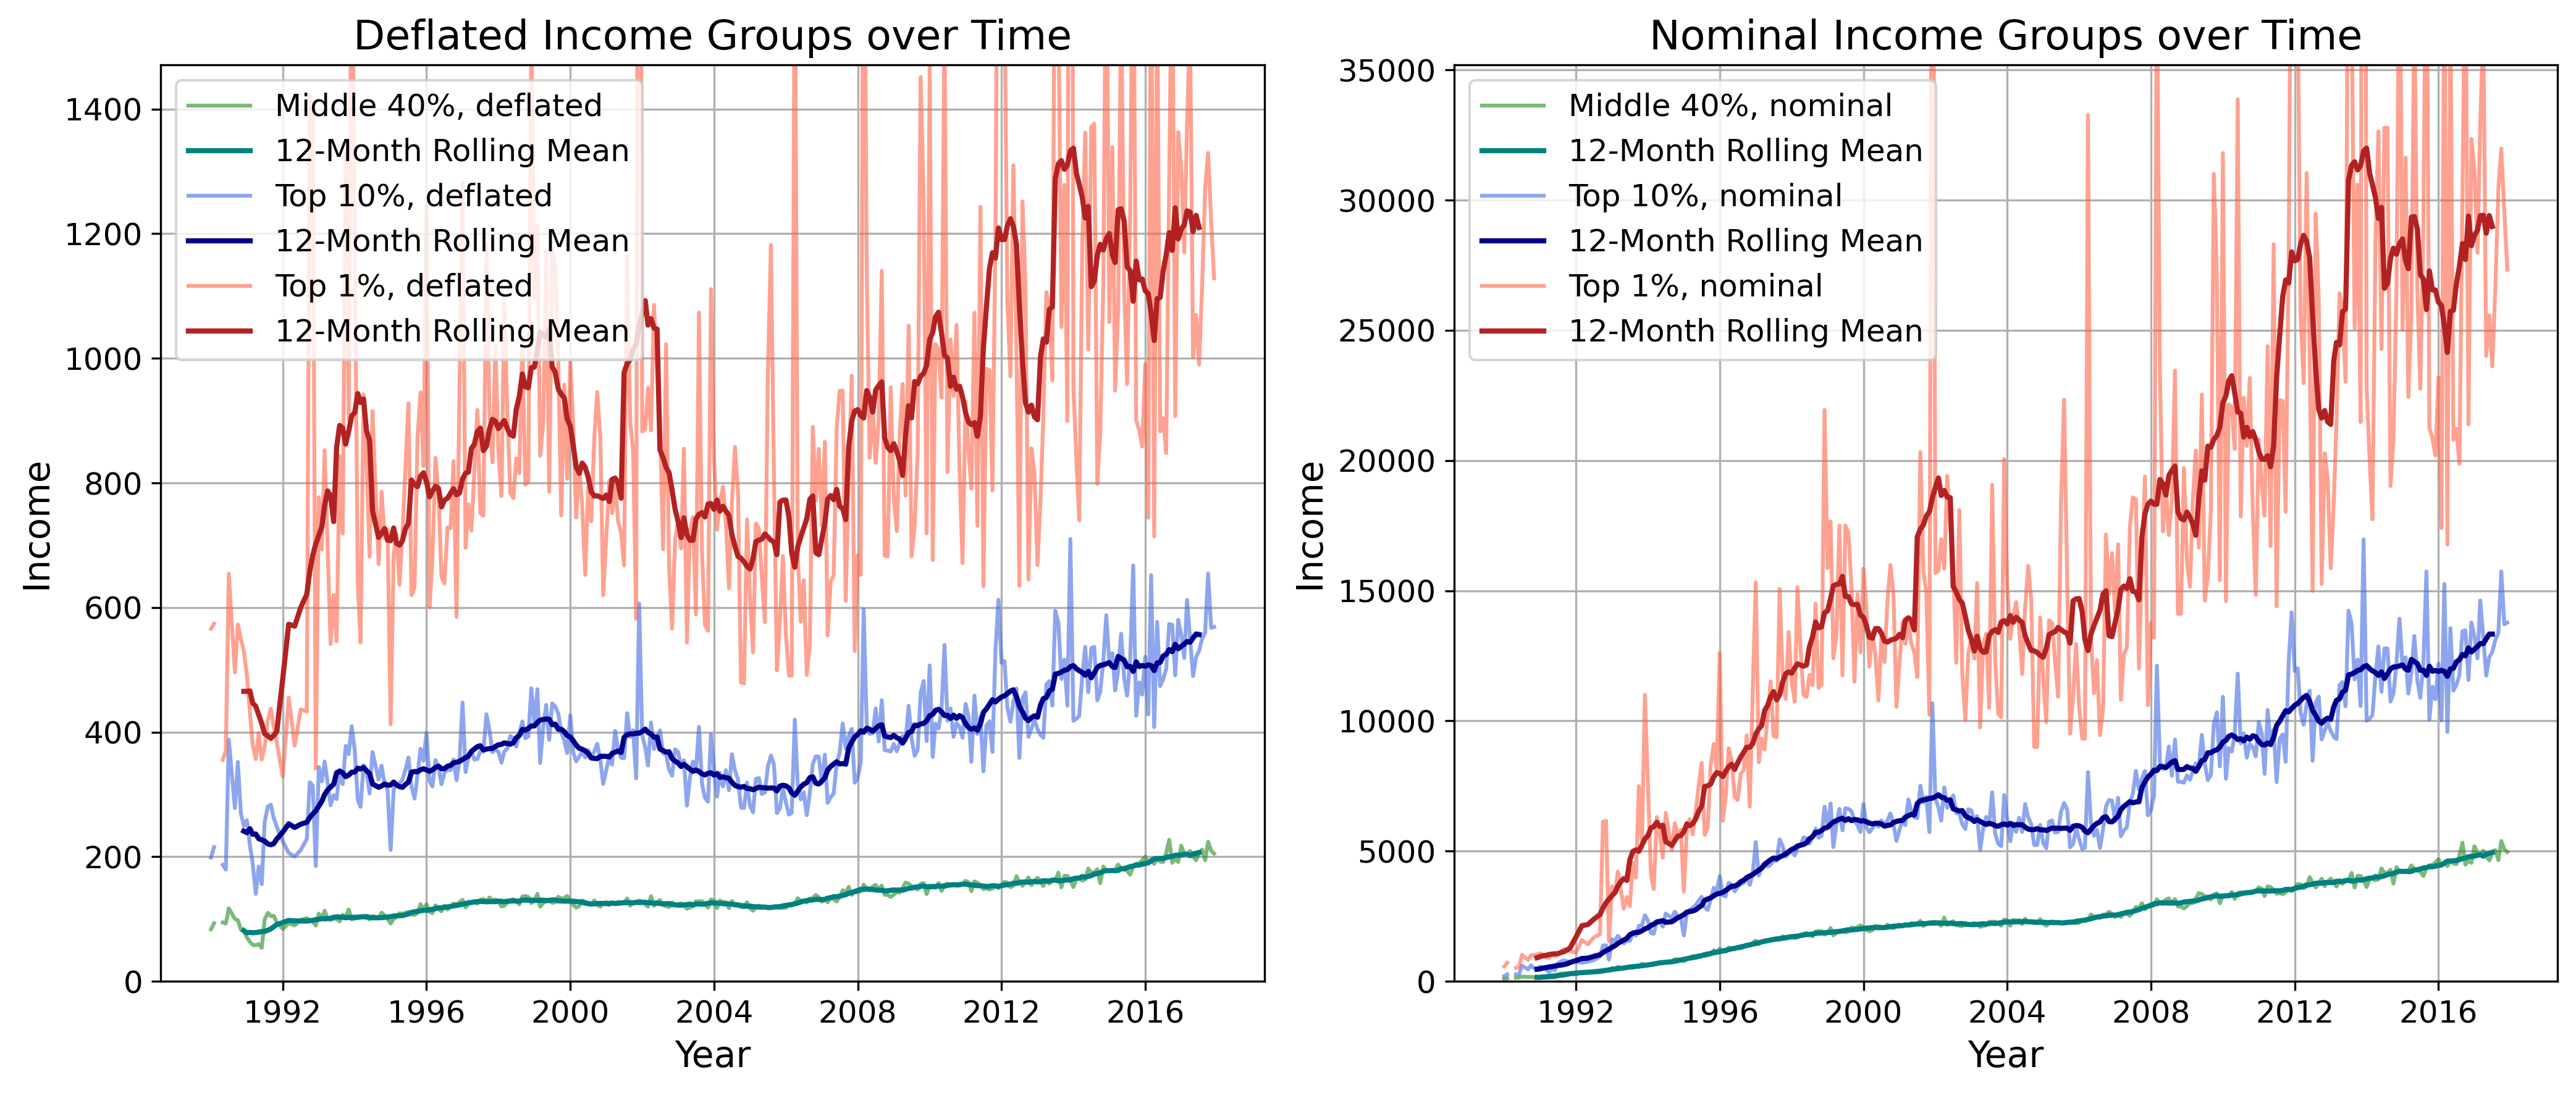

In [19]:
# 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(IA_defl.time_series.index, m40_defl, label='Middle 40%, deflated', color='forestgreen', alpha=0.6)
roll_mean_med_defl = pd.Series(m40_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_med_defl, label='12-Month Rolling Mean', color='teal', linewidth=2)
ax[0].plot(IA_defl.time_series.index, t10_defl, label='Top 10%, deflated', color='royalblue', alpha=0.6)
roll_mean_t10_defl = pd.Series(t10_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_t10_defl, label='12-Month Rolling Mean', color='darkblue', linewidth=2)
ax[0].plot(IA_defl.time_series.index, t1_defl, label='Top 1%, deflated', color='tomato', alpha=0.6)
roll_mean_t1_defl = pd.Series(t1_defl).rolling(window=12, center=True).mean()
ax[0].plot(IA_defl.time_series.index, roll_mean_t1_defl, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[0].set_title('Deflated Income Groups over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Income')
ax[1].plot(IA.time_series.index, m40, label='Middle 40%, nominal', color='forestgreen', alpha=0.6)
roll_mean_med = pd.Series(m40).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean_med, label='12-Month Rolling Mean', color='teal', linewidth=2)
ax[1].plot(IA.time_series.index, t10, label='Top 10%, nominal', color='royalblue', alpha=0.6)
roll_mean_t10 = pd.Series(t10).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean_t10, label='12-Month Rolling Mean', color='darkblue', linewidth=2)
ax[1].plot(IA.time_series.index, t1, label='Top 1%, nominal', color='tomato', alpha=0.6)
roll_mean_t1 = pd.Series(t1).rolling(window=12, center=True).mean()
ax[1].plot(IA.time_series.index, roll_mean_t1, label='12-Month Rolling Mean', color='firebrick', linewidth=2)
ax[1].set_title('Nominal Income Groups over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Income')
# set limits on y-axis to better see the differences
ax[0].set_ylim(0, np.max(roll_mean_t1_defl)*1.1)
ax[1].set_ylim(0, np.max(roll_mean_t1)*1.1)
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_6_income_groups_comparison_top40.png', dpi =300)
plt.show()

In [20]:
defl = IA_defl.compute_income_shares()

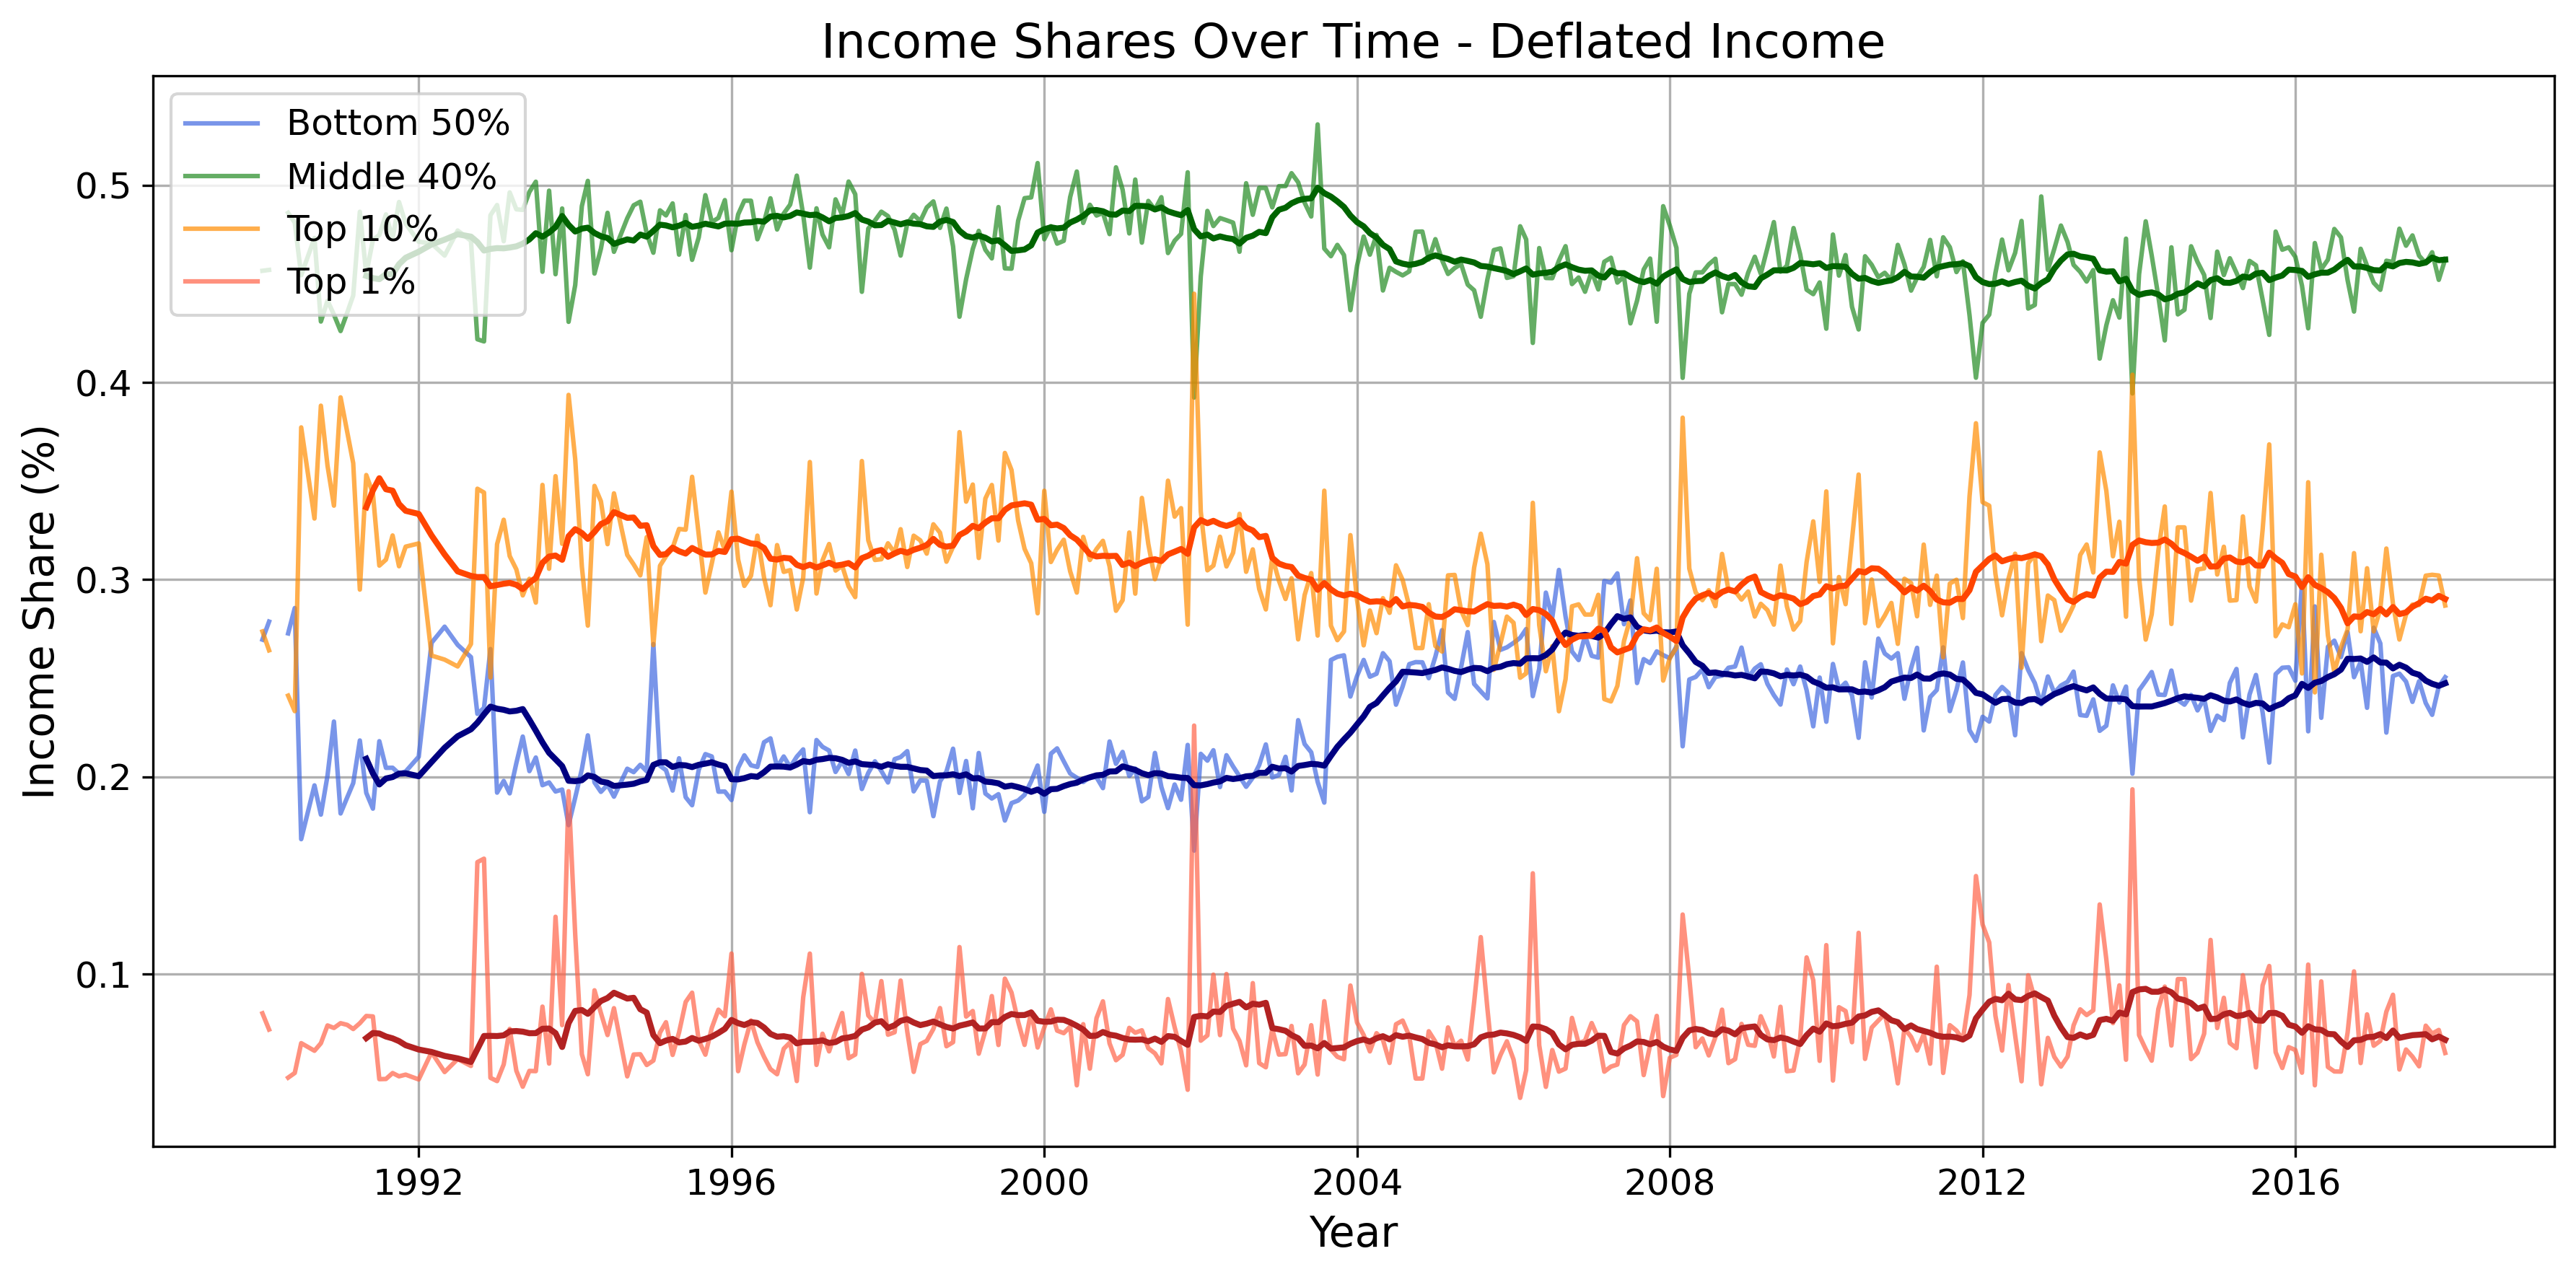

In [21]:
# plot on one plot income shares over time for bottom 50%, middle 40%, top 10%, top 1%
plt.figure(figsize=(12,6))
plt.plot(defl.index, defl['bottom_50'], label='Bottom 50%', color='royalblue', alpha=0.7)
plt.plot(defl.index, defl['middle_40'], label='Middle 40%', color='forestgreen', alpha=0.7)
plt.plot(defl.index, defl['top_10'], label='Top 10%', color='darkorange', alpha=0.7)
plt.plot(defl.index, defl['top_1'], label='Top 1%', color='tomato', alpha=0.7)
# rolling means
roll_b50 = defl['bottom_50'].rolling(window=12).mean()
roll_m40 = defl['middle_40'].rolling(window=12).mean()
roll_t10 = defl['top_10'].rolling(window=12).mean()
roll_t1 = defl['top_1'].rolling(window=12).mean()
plt.plot(defl.index, roll_b50, color='navy', linewidth=2)
plt.plot(defl.index, roll_m40, color='darkgreen', linewidth=2)
plt.plot(defl.index, roll_t10, color='orangered', linewidth=2)
plt.plot(defl.index, roll_t1, color='firebrick', linewidth=2)
plt.title('Income Shares Over Time - Deflated Income')
plt.xlabel('Year')
plt.ylabel('Income Share (%)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(plot_root / 'CBOS_04_7_income_shares_deflated.png', dpi =300)
plt.show()


In [22]:
# reload luf
import importlib
importlib.reload(luf)

<module 'local_utility_functions' from '/Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper/Code/tools/local_utility_functions.py'>

In [23]:
from pandas.errors import ParserError

lis_root = data_root.parent / "LIS outputs"

file = lis_root / "incomeh_evolution.csv"
incomeh_evolution = pd.read_csv(file, engine='python', encoding='utf-8')



In [24]:
# Change year column to datetime (1986 -> 1986-12-31)
incomeh_evolution['year'] = pd.to_datetime(incomeh_evolution['year'].astype(str) + '-01-01', format='%Y-%m-%d')
incomeh_evolution.index = incomeh_evolution['year']
incomeh_evolution

,year,mean_incomeh,median_incomeh
year,,,
1986-01-01,1986-01-01,41.12,38.12
1992-01-01,1992-01-01,3485.01,2826.65
1995-01-01,1995-01-01,6268.54,4693.20
1999-01-01,1999-01-01,13454.88,10573.20
2004-01-01,2004-01-01,16002.53,11376.00
2005-01-01,2005-01-01,16277.49,11621.40
2006-01-01,2006-01-01,17955.80,13091.04
2007-01-01,2007-01-01,20882.62,15600.00
2008-01-01,2008-01-01,24353.35,18180.00


In [25]:
# Deflate yearly LIS income data using the improved function
# Note: dividing by 12 to convert annual to monthly equivalent
incomeh_evolution_delf = luf.deflate_income(
    income_series=pd.Series(incomeh_evolution['mean_incomeh']/12),
    cpi_series=org_inflation_data['inflation_index'],
    ref_date=pd.Timestamp('1990-01-01'),
    income_freq='A',  # annual data
    cpi_is_rate=True,  # inflation_index contains month-to-month ratios
    use_exact_dates=False  # use year-end dates for annual data
)

incomeh_evolution_med_defl = luf.deflate_income(
    income_series=pd.Series(incomeh_evolution['median_incomeh']/12),
    cpi_series=org_inflation_data['inflation_index'],
    ref_date=pd.Timestamp('1990-01-01'),
    income_freq='A',
    cpi_is_rate=True,
    use_exact_dates=False
)

## Summary: Robust `deflate_income()` Function

The improved `deflate_income()` function in the `luf` module now handles both use cases:

### Use Case 1: Dataframe with Multiple Observations per Date (Cell 3)
- **Data**: Monthly survey data (CBOS) with multiple households per survey date
- **Solution**: Create dummy series with unique dates, compute deflation factors, map to dataframe
- **Parameters**: `income_freq='M'`, `cpi_is_rate=True`, `use_exact_dates=True`
- **Result**: ✓ Deflation factor = 1.0 at reference date (1990-01-01)

### Use Case 2: Yearly Income Time Series (Cell 23)
- **Data**: Annual aggregate statistics (LIS) with one value per year  
- **Solution**: Pass series directly to function
- **Parameters**: `income_freq='A'`, `cpi_is_rate=True`, `use_exact_dates=False`
- **Result**: ✓ Properly deflated using year-end CPI values

### Key Improvements:
1. **`cpi_is_rate` parameter**: Converts month-to-month ratios (100, 123.8, 104.3) to cumulative CPI
2. **Automatic normalization**: Sets CPI=100 at reference date
3. **`use_exact_dates` parameter**: Controls whether to use exact dates or period-end dates
4. **Works with any reference date**: Including dates at the start, middle, or end of the time series

In [26]:
# Final demonstration: Both use cases side by side
print("=" * 80)
print("DEMONSTRATION: Robust deflate_income() Function")
print("=" * 80)

print("\n📊 USE CASE 1: Monthly Survey Data (CBOS) - Multiple observations per date")
print("-" * 80)
print(f"Data shape: {df.shape[0]:,} observations")
print(f"Unique survey dates: {len(unique_dates)}")
print(f"Reference date: {ref_date}")
print(f"Function call: deflate_income(..., income_freq='M', cpi_is_rate=True, use_exact_dates=True)")
print(f"\nSample results:")
print(f"  At ref_date {ref_date}: deflation_factor = {deflation_factors[ref_date]:.6f} ✓")
print(f"  At 2000-01-01: deflation_factor = {deflation_factors[pd.Timestamp('2000-01-01')]:.6f}")
print(f"  → Income values at ref_date unchanged, later values adjusted for inflation")

print("\n\n📈 USE CASE 2: Yearly Aggregate Data (LIS) - One value per year")
print("-" * 80)
print(f"Data shape: {len(incomeh_evolution)} years (1986-2024)")
print(f"Reference date: {ref_date}")
print(f"Function call: deflate_income(..., income_freq='A', cpi_is_rate=True, use_exact_dates=False)")
print(f"\nSample results:")
print(f"  1986 income: {incomeh_evolution['mean_incomeh'].iloc[0]/12:.2f} → {incomeh_evolution_delf.iloc[0]:.2f}")
print(f"  1995 income: {incomeh_evolution['mean_incomeh'].iloc[2]/12:.2f} → {incomeh_evolution_delf.iloc[2]:.2f}")
print(f"  → Uses year-end CPI values for annual data")

print("\n\n✅ CONCLUSION")
print("-" * 80)
print("The deflate_income() function correctly handles:")
print("  1. Different data frequencies (monthly, yearly)")
print("  2. Multiple observations per date (via dummy series approach)")
print("  3. Month-to-month CPI ratios (automatic conversion to cumulative index)")
print("  4. Reference dates at any position in the time series")
print("  5. Exact dates vs. period-end dates (controlled by use_exact_dates parameter)")
print("=" * 80)

DEMONSTRATION: Robust deflate_income() Function

📊 USE CASE 1: Monthly Survey Data (CBOS) - Multiple observations per date
--------------------------------------------------------------------------------
Data shape: 358,525 observations
Unique survey dates: 329
Reference date: 1990-01-01 00:00:00
Function call: deflate_income(..., income_freq='M', cpi_is_rate=True, use_exact_dates=True)

Sample results:
  At ref_date 1990-01-01 00:00:00: deflation_factor = 1.000000 ✓
  At 2000-01-01: deflation_factor = 0.062728
  → Income values at ref_date unchanged, later values adjusted for inflation


📈 USE CASE 2: Yearly Aggregate Data (LIS) - One value per year
--------------------------------------------------------------------------------
Data shape: 24 years (1986-2024)
Reference date: 1990-01-01 00:00:00
Function call: deflate_income(..., income_freq='A', cpi_is_rate=True, use_exact_dates=False)

Sample results:
  1986 income: 3.43 → 100.31
  1995 income: 522.38 → 51.68
  → Uses year-end CPI 

In [27]:
incomeh_evolution_delf

year
1986-01-01    100.309455
1992-01-01     62.023277
1995-01-01     51.678967
1999-01-01     70.373181
2004-01-01     70.699043
2005-01-01     71.345943
2006-01-01     77.462461
2007-01-01     86.405442
2008-01-01     97.693232
2009-01-01     98.975317
2010-01-01    102.610916
2011-01-01    101.777030
2012-01-01    101.982230
2013-01-01    102.228315
2014-01-01    104.838797
2015-01-01    109.172118
2016-01-01    110.686887
2017-01-01    117.512588
2018-01-01    121.775546
2019-01-01    123.916321
2020-01-01    131.304492
2021-01-01    127.282194
2022-01-01    118.158173
2023-01-01    128.113979
Name: mean_incomeh_real_1990-01-01, dtype: float64

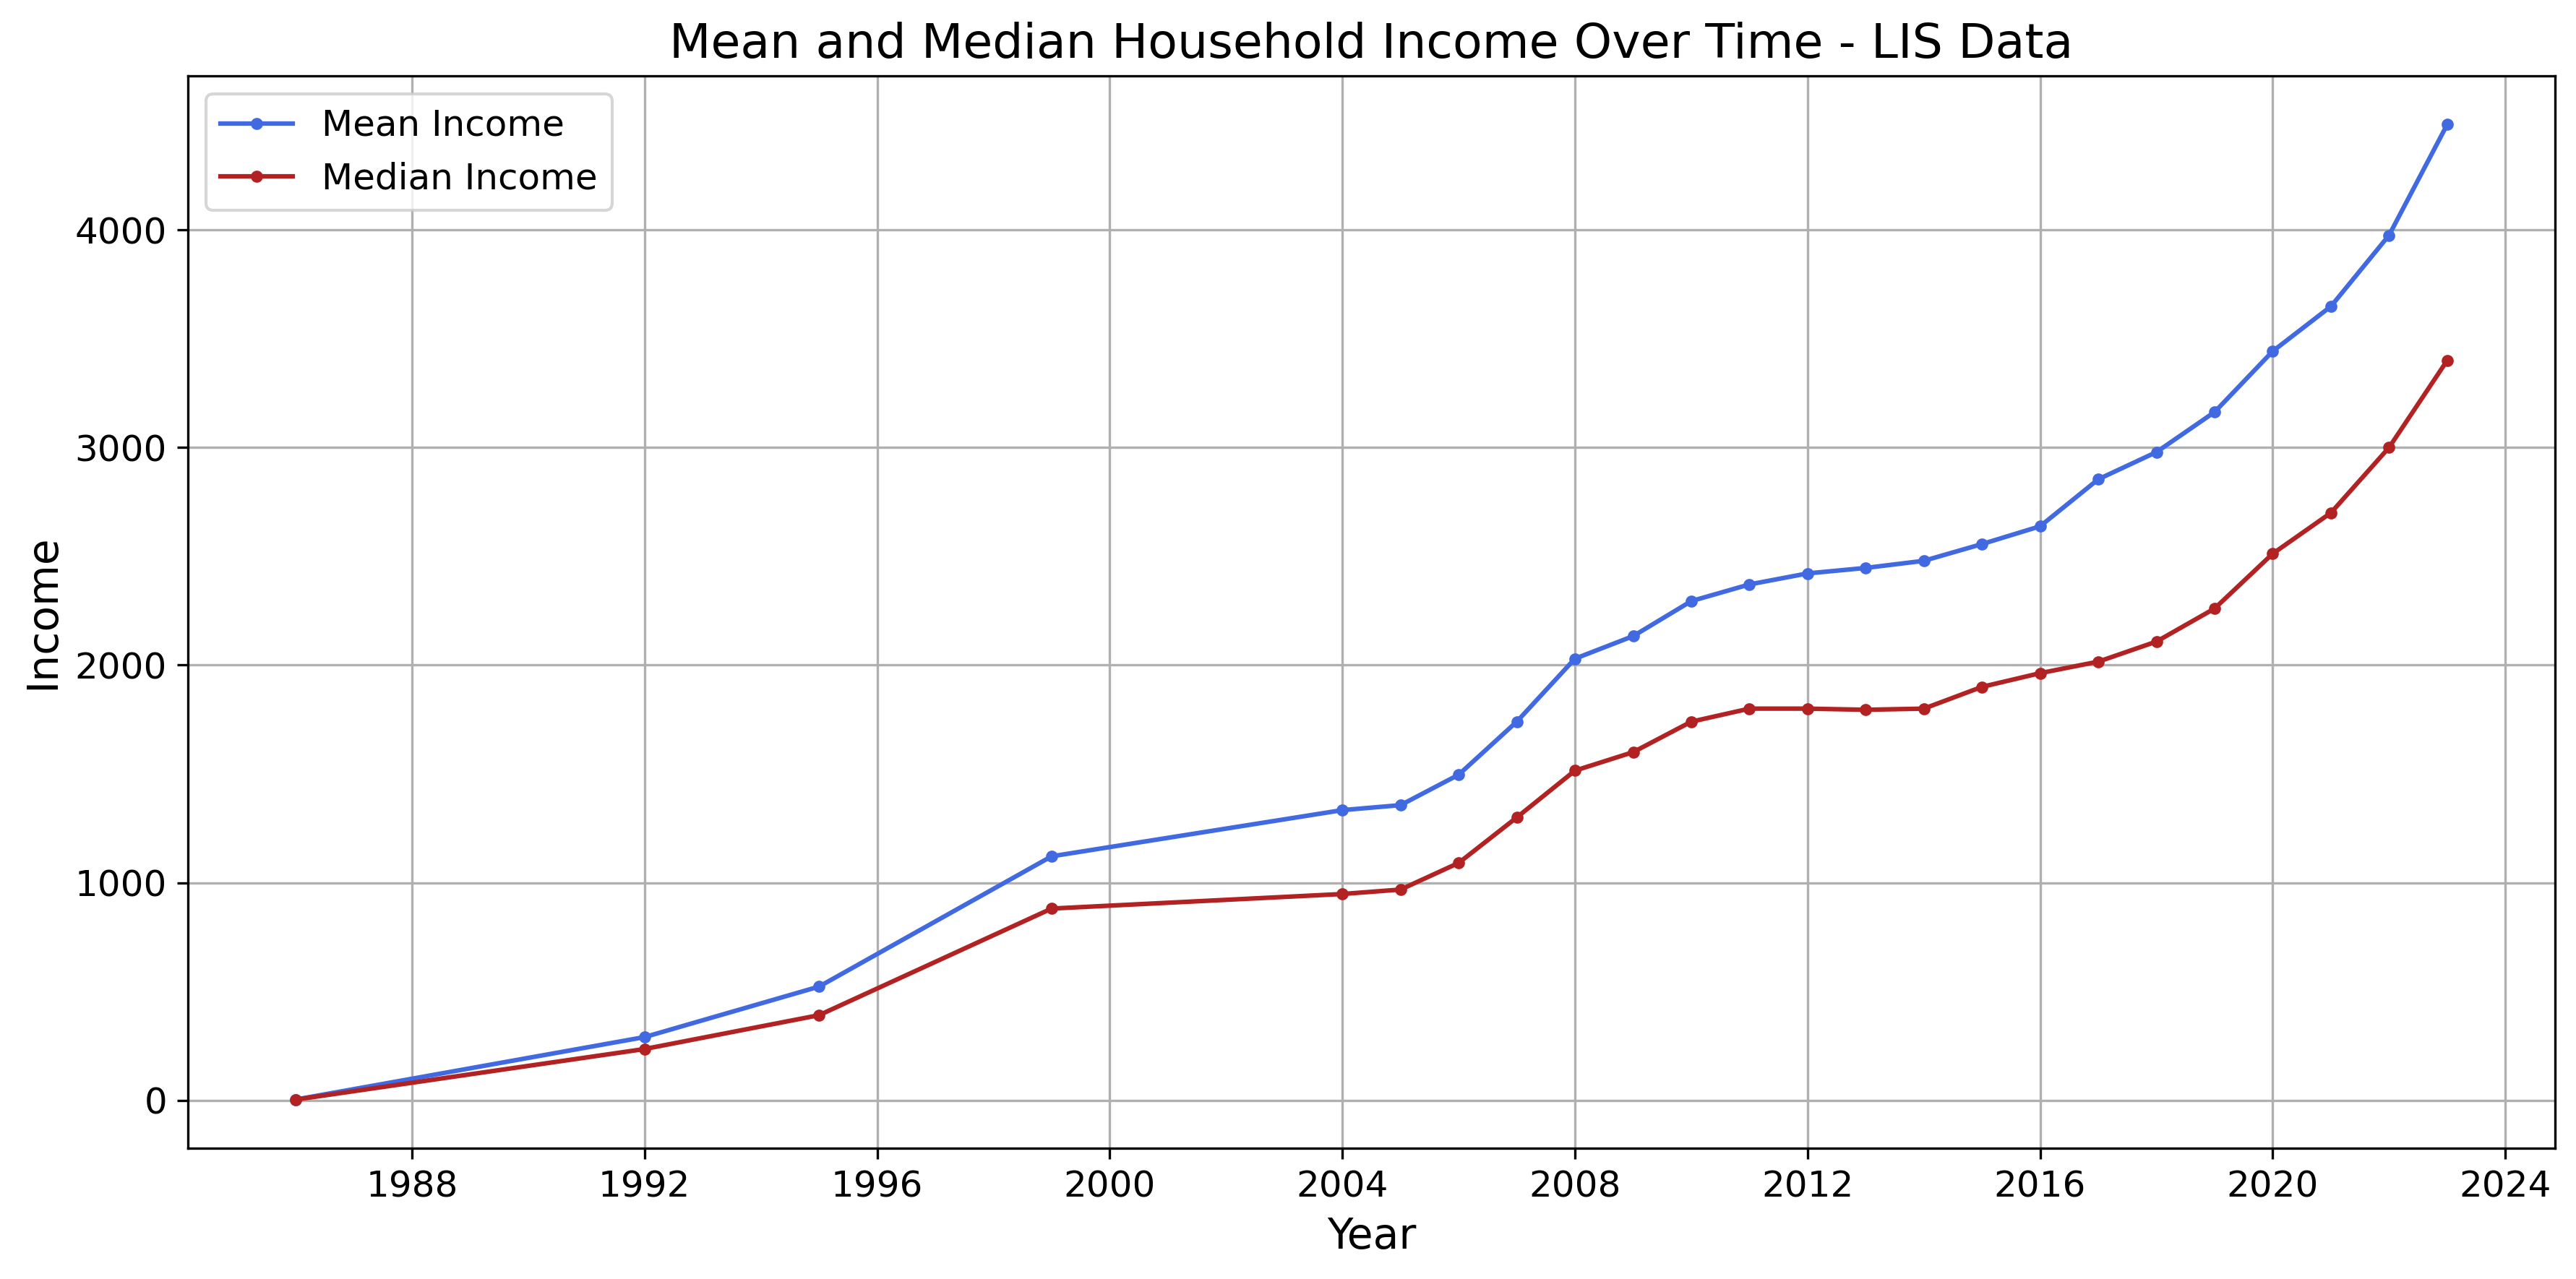

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(incomeh_evolution['year'], incomeh_evolution['mean_incomeh']/12, marker='.', label='Mean Income', color='royalblue')
plt.plot(incomeh_evolution['year'], incomeh_evolution['median_incomeh']/12, marker='.', label='Median Income', color='firebrick')
plt.title('Mean and Median Household Income Over Time - LIS Data')
plt.xlabel('Year')
plt.ylabel('Income')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_1_mean_median.png', dpi =300)
plt.show()

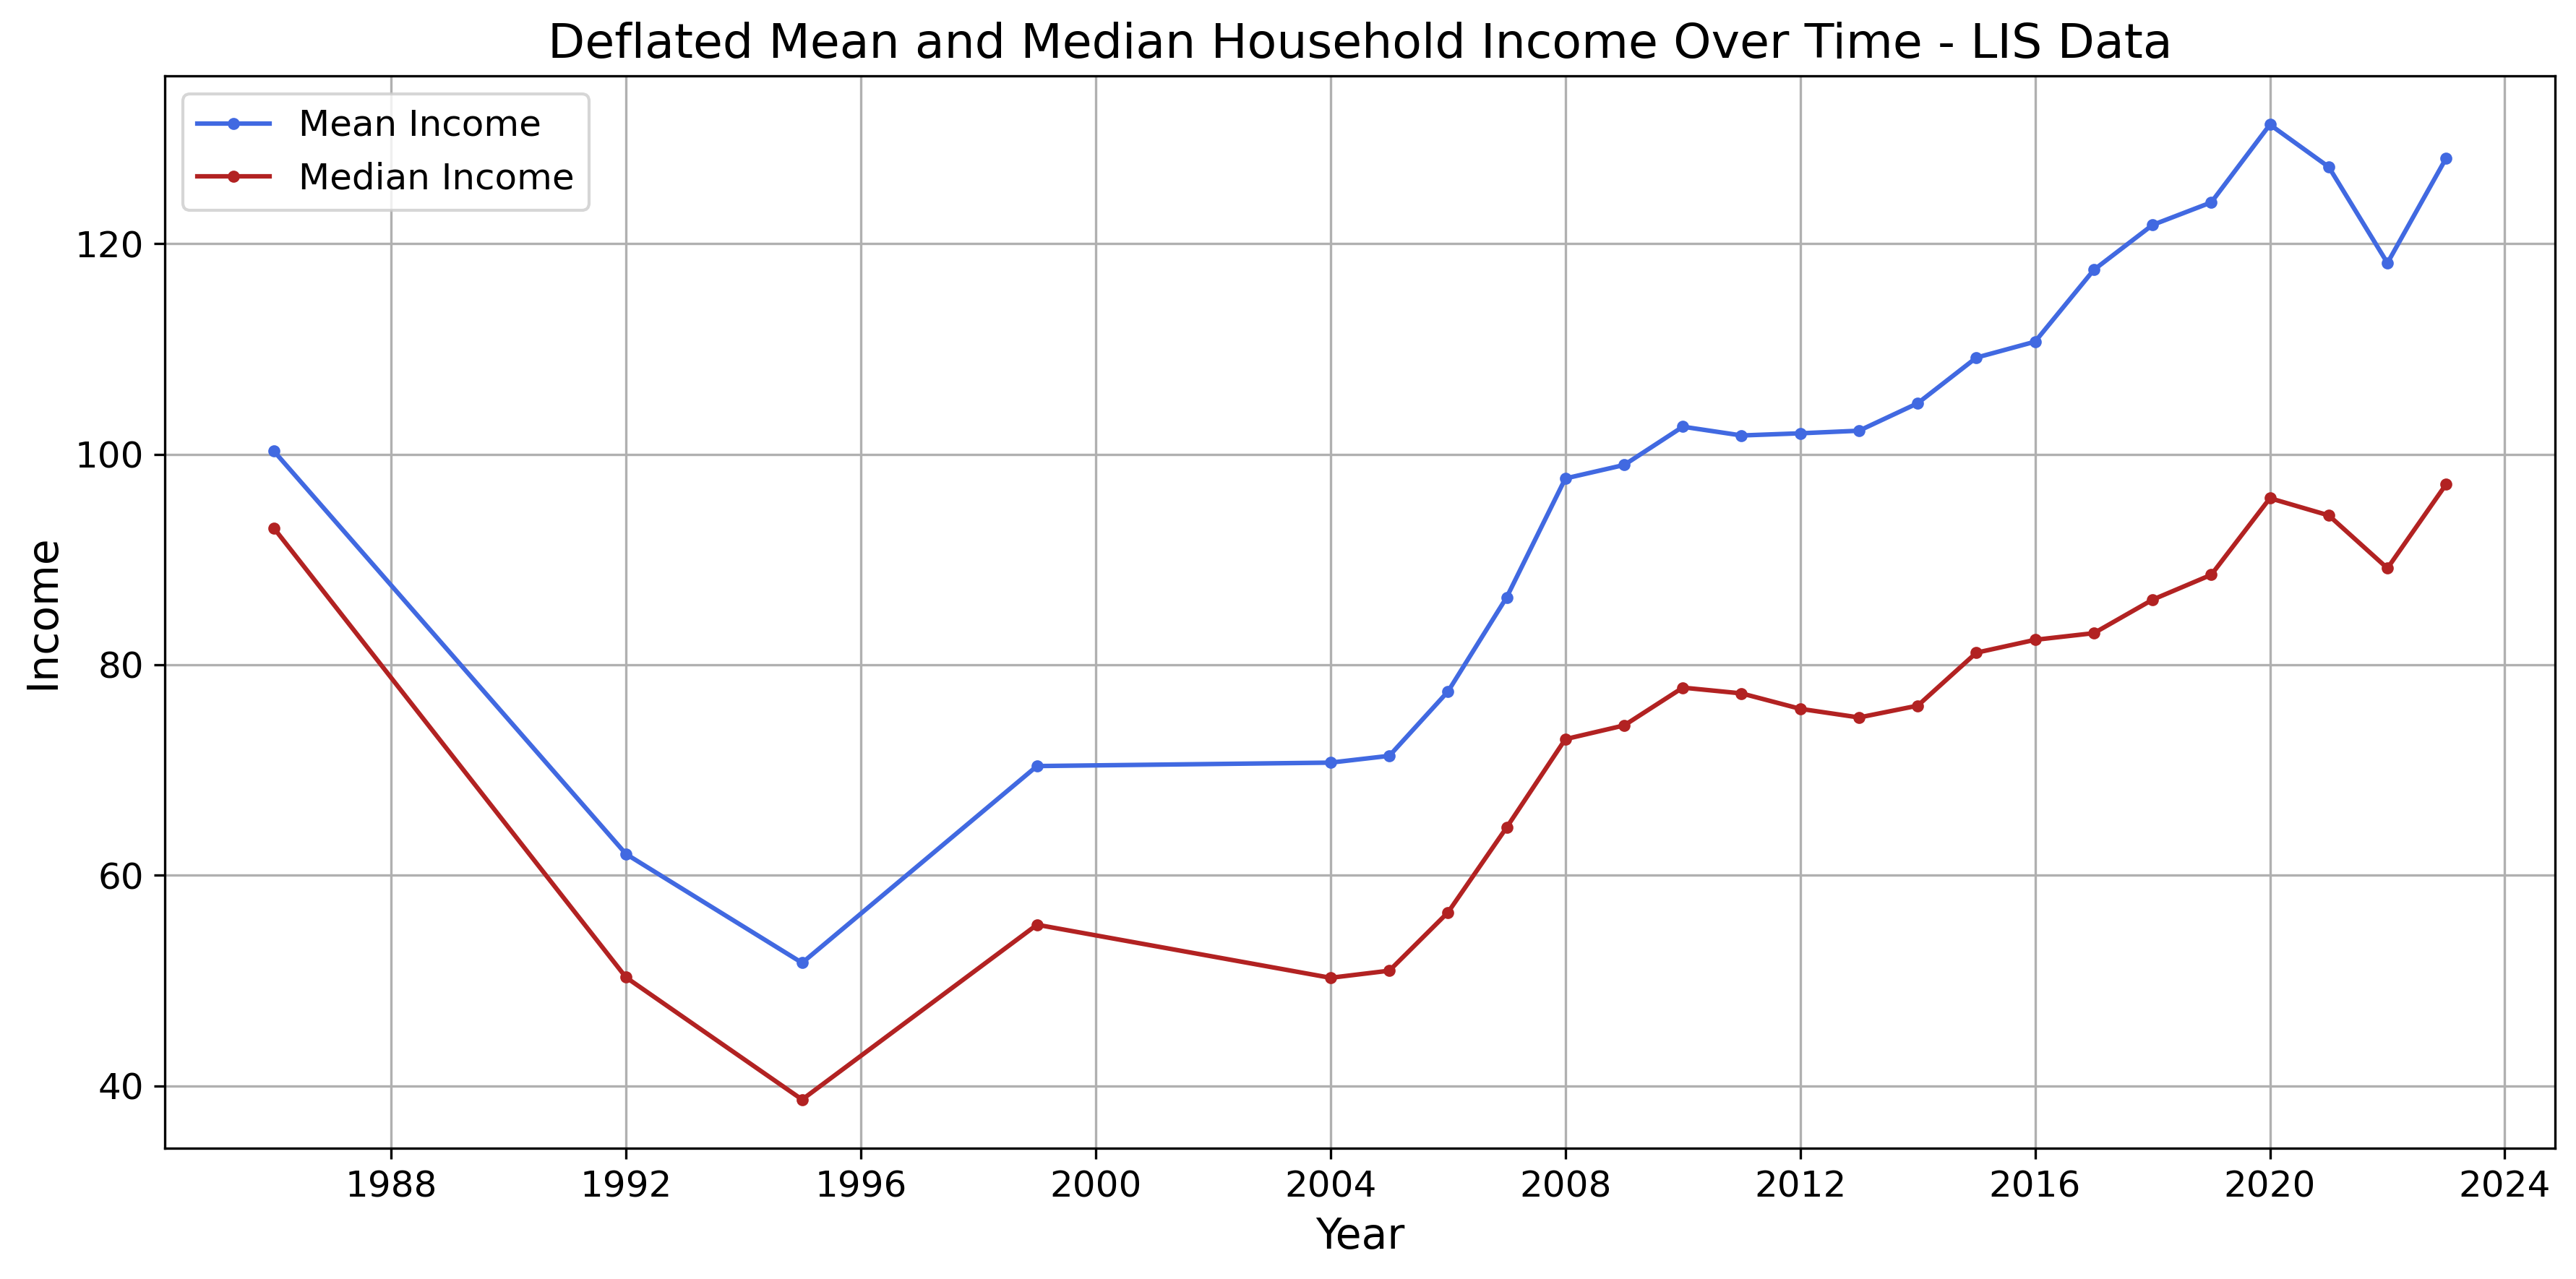

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(incomeh_evolution['year'], incomeh_evolution_delf.values, marker='.', label='Mean Income', color='royalblue')
plt.plot(incomeh_evolution['year'], incomeh_evolution_med_defl.values, marker='.', label='Median Income', color='firebrick')
plt.title('Deflated Mean and Median Household Income Over Time - LIS Data')
plt.xlabel('Year')
plt.ylabel('Income')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_1_mean_median_defl.png', dpi =300)
plt.show()

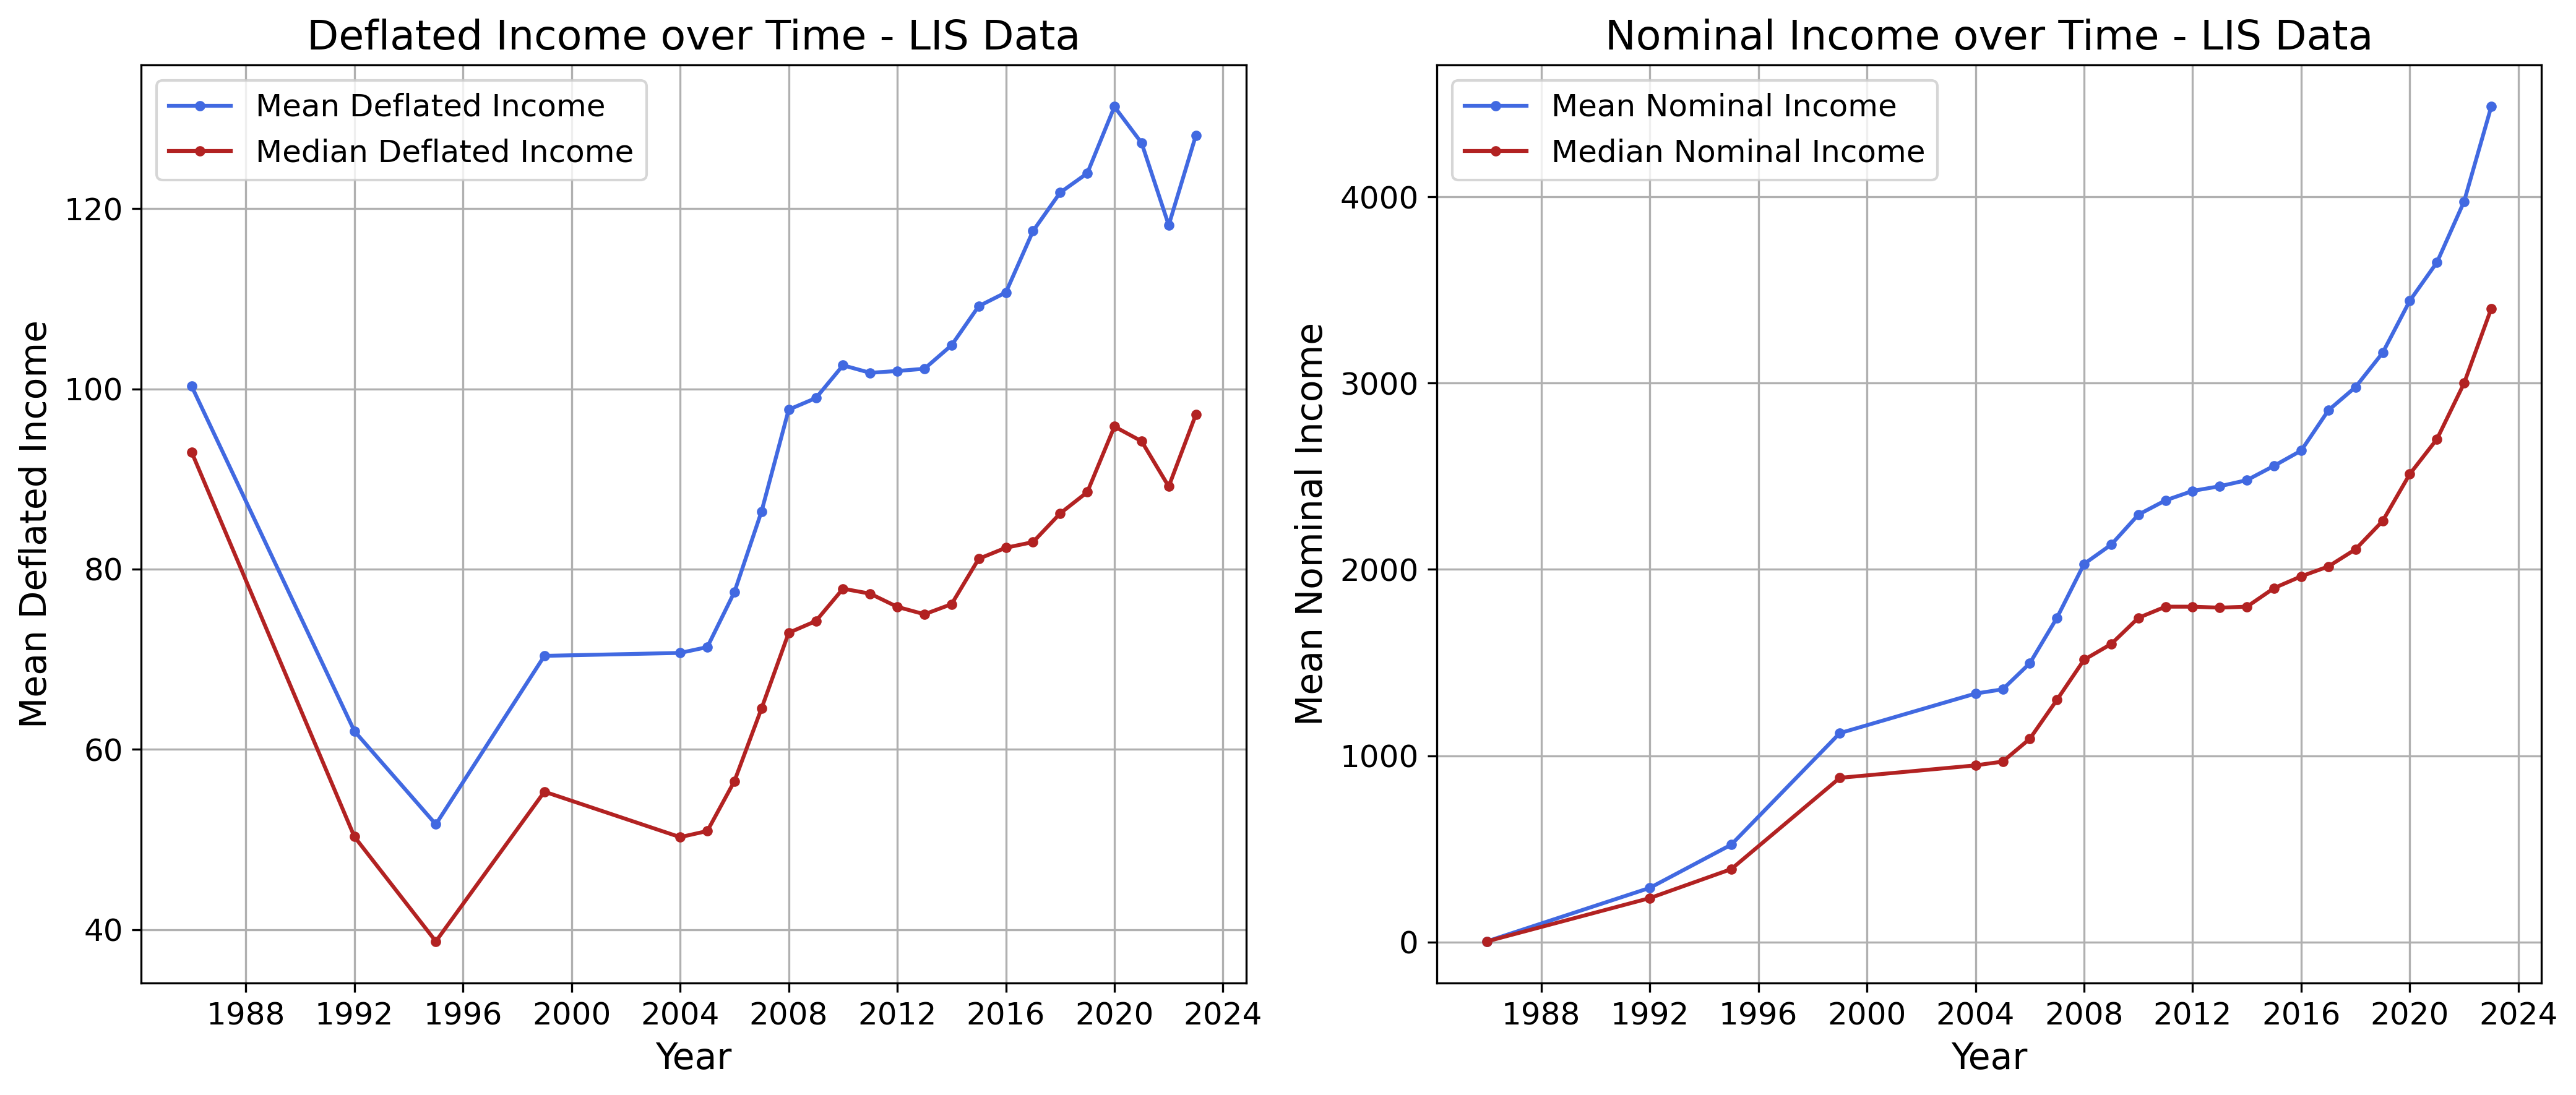

In [30]:
# plot means over time
import matplotlib.pyplot as plt


# 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(incomeh_evolution['year'], incomeh_evolution_delf.values, label='Mean Deflated Income', color='royalblue', marker='.')
ax[0].plot(incomeh_evolution['year'], incomeh_evolution_med_defl.values, label='Median Deflated Income', color='firebrick', marker='.')
ax[0].set_title('Deflated Income over Time - LIS Data')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Mean Deflated Income')
ax[1].plot(incomeh_evolution['year'], incomeh_evolution['mean_incomeh']/12, color='royalblue', label='Mean Nominal Income', marker='.')
ax[1].plot(incomeh_evolution['year'], incomeh_evolution['median_incomeh']/12, label='Median Nominal Income', color='firebrick', marker='.')
ax[1].set_title('Nominal Income over Time - LIS Data')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Mean Nominal Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_2_income_comparison.png', dpi =300)
plt.show()

In [31]:
income_groups_path = lis_root / 'raw outputs' / 'lis_income_groups.txt'
income_groups_save_path = lis_root / 'lis_income_groups.csv'
incomeh_groups_evolution = luf.adapt_txt(file_path= income_groups_path, save_path= income_groups_save_path)

In [32]:
# Change year column to datetime (1986 -> 1986-12-31)
incomeh_groups_evolution['year'] = pd.to_datetime(incomeh_groups_evolution['year'].astype(str) + '-01-01', format='%Y-%m-%d')
incomeh_groups_evolution.index = incomeh_groups_evolution['year']
incomeh_groups_evolution

,year,hitotal,hicash,hinoncap,hitotal_Bottom_50,hitotal_P50_90,hitotal_Top_10,hitotal_Top_1,hicash_Bottom_50,hicash_P50_90,hicash_Top_10,hicash_Top_1,hinoncap_Bottom_50,hinoncap_P50_90,hinoncap_Top_10,hinoncap_Top_1
year,,,,,,,,,,,,,,,,
1986-01-01,1986-01-01,50.06,50.06,50.06,26.74,62.40,117.31,211.75,26.74,62.40,117.31,211.75,26.74,62.40,117.31,211.75
1992-01-01,1992-01-01,5646.40,5451.57,5403.69,3209.74,6806.20,13181.32,24443.21,3052.68,6588.93,12888.40,23829.34,3033.55,6544.48,12686.09,22824.28
1995-01-01,1995-01-01,10209.63,10209.63,10182.50,5168.31,12205.80,27425.77,66261.61,5168.31,12205.80,27425.77,66261.61,5155.10,12182.74,27313.80,65977.79
1999-01-01,1999-01-01,20806.13,20396.80,20345.27,11541.48,24673.67,51649.61,111173.76,11231.14,24232.89,50876.28,109757.73,11204.90,24183.67,50691.88,109215.99
2004-01-01,2004-01-01,24903.62,24309.56,24226.42,12982.02,29530.30,65995.17,141791.09,12518.79,28911.67,64845.23,140116.01,12476.58,28840.74,64505.63,138712.59
2005-01-01,2005-01-01,25638.51,25026.74,24937.30,13383.44,30449.34,67667.78,141669.42,12903.79,29841.30,66378.04,138531.16,12854.37,29750.05,66100.37,137544.30
2006-01-01,2006-01-01,28104.77,27413.55,27326.09,14649.86,33458.56,73961.42,156000.82,14166.69,32718.95,72414.89,153301.96,14126.94,32632.77,72087.66,152071.70
2007-01-01,2007-01-01,31390.97,30699.35,30558.35,16048.83,37105.34,85233.67,192982.90,15601.48,36356.17,83550.17,190032.32,15552.55,36247.36,82825.40,186698.46
2008-01-01,2008-01-01,35697.07,34527.71,34401.19,17859.97,42797.42,96471.81,207532.07,17411.94,41732.73,91272.51,193147.50,17353.88,41612.96,90783.22,191977.79


In [33]:
columns = ['hitotal_Bottom_50', 'hitotal_P50_90', 'hitotal_Top_10', 'hitotal_Top_1', 'hinoncap_Bottom_50', 'hinoncap_P50_90', 'hinoncap_Top_10', 'hinoncap_Top_1']

In [34]:
# Deflate all income group columns in incomeh_groups_evolution
# Loop through each column and create a deflated version with '_defl' suffix

for col in columns:
    # Deflate the column values (already monthly, no need to divide by 12)
    deflated_series = luf.deflate_income(
        income_series=pd.Series(incomeh_groups_evolution[col]),
        cpi_series=org_inflation_data['inflation_index'],
        ref_date=pd.Timestamp('1990-01-01'),
        income_freq='Y',  # annual data
        cpi_is_rate=True,  # inflation_index contains month-to-month ratios
        use_exact_dates=False  # use year-end dates for annual data
    )
    
    # Add deflated column with '_defl' suffix
    incomeh_groups_evolution[f'{col}_defl'] = deflated_series.values

print(f"✓ Deflated {len(columns)} income group columns")
print(f"New columns created: {[f'{col}_defl' for col in columns]}")

✓ Deflated 8 income group columns
New columns created: ['hitotal_Bottom_50_defl', 'hitotal_P50_90_defl', 'hitotal_Top_10_defl', 'hitotal_Top_1_defl', 'hinoncap_Bottom_50_defl', 'hinoncap_P50_90_defl', 'hinoncap_Top_10_defl', 'hinoncap_Top_1_defl']


In [38]:
incomeh_groups_evolution

,year,hitotal,hicash,hinoncap,hitotal_Bottom_50,hitotal_P50_90,hitotal_Top_10,hitotal_Top_1,hicash_Bottom_50,hicash_P50_90,...,hinoncap_Top_10,hinoncap_Top_1,hitotal_Bottom_50_defl,hitotal_P50_90_defl,hitotal_Top_10_defl,hitotal_Top_1_defl,hinoncap_Bottom_50_defl,hinoncap_P50_90_defl,hinoncap_Top_10_defl,hinoncap_Top_1_defl
year,,,,,,,,,,,,,,,,,,,,,
1986-01-01,1986-01-01,50.06,50.06,50.06,26.74,62.40,117.31,211.75,26.74,62.40,...,117.31,211.75,782.765026,1826.646882,3434.037593,6198.597393,782.765026,1826.646882,3434.037593,6198.597393
1992-01-01,1992-01-01,5646.40,5451.57,5403.69,3209.74,6806.20,13181.32,24443.21,3052.68,6588.93,...,12686.09,22824.28,685.491035,1453.572277,2815.080563,5220.236316,647.862857,1397.677808,2709.316318,4874.488062
1995-01-01,1995-01-01,10209.63,10209.63,10182.50,5168.31,12205.80,27425.77,66261.61,5168.31,12205.80,...,27313.80,65977.79,511.301689,1207.521639,2713.235571,6555.271092,509.994822,1205.240310,2702.158362,6527.192737
1999-01-01,1999-01-01,20806.13,20396.80,20345.27,11541.48,24673.67,51649.61,111173.76,11231.14,24232.89,...,50691.88,109215.99,724.386093,1548.611045,3241.721094,6977.677525,703.261083,1517.856827,3181.610407,6854.800619
2004-01-01,2004-01-01,24903.62,24309.56,24226.42,12982.02,29530.30,65995.17,141791.09,12518.79,28911.67,...,64505.63,138712.59,688.253466,1565.575413,3498.793292,7517.182159,661.457110,1529.017770,3419.823989,7353.972713
2005-01-01,2005-01-01,25638.51,25026.74,24937.30,13383.44,30449.34,67667.78,141669.42,12903.79,29841.30,...,66100.37,137544.30,703.932223,1601.551738,3559.139563,7451.422783,676.104593,1564.771003,3476.698098,7234.452790
2006-01-01,2006-01-01,28104.77,27413.55,27326.09,14649.86,33458.56,73961.42,156000.82,14166.69,32718.95,...,72087.66,152071.70,758.405115,1732.108227,3828.891144,8075.969312,731.334194,1689.358101,3731.888909,7872.563634
2007-01-01,2007-01-01,31390.97,30699.35,30558.35,16048.83,37105.34,85233.67,192982.90,15601.48,36356.17,...,82825.40,186698.46,796.857622,1842.356919,4232.028103,9582.000355,772.216293,1799.756436,4112.452514,9269.964904
2008-01-01,2008-01-01,35697.07,34527.71,34401.19,17859.97,42797.42,96471.81,207532.07,17411.94,41732.73,...,90783.22,191977.79,859.741202,2060.177331,4643.949005,9990.155155,835.379099,2003.159930,4370.112307,9241.404995


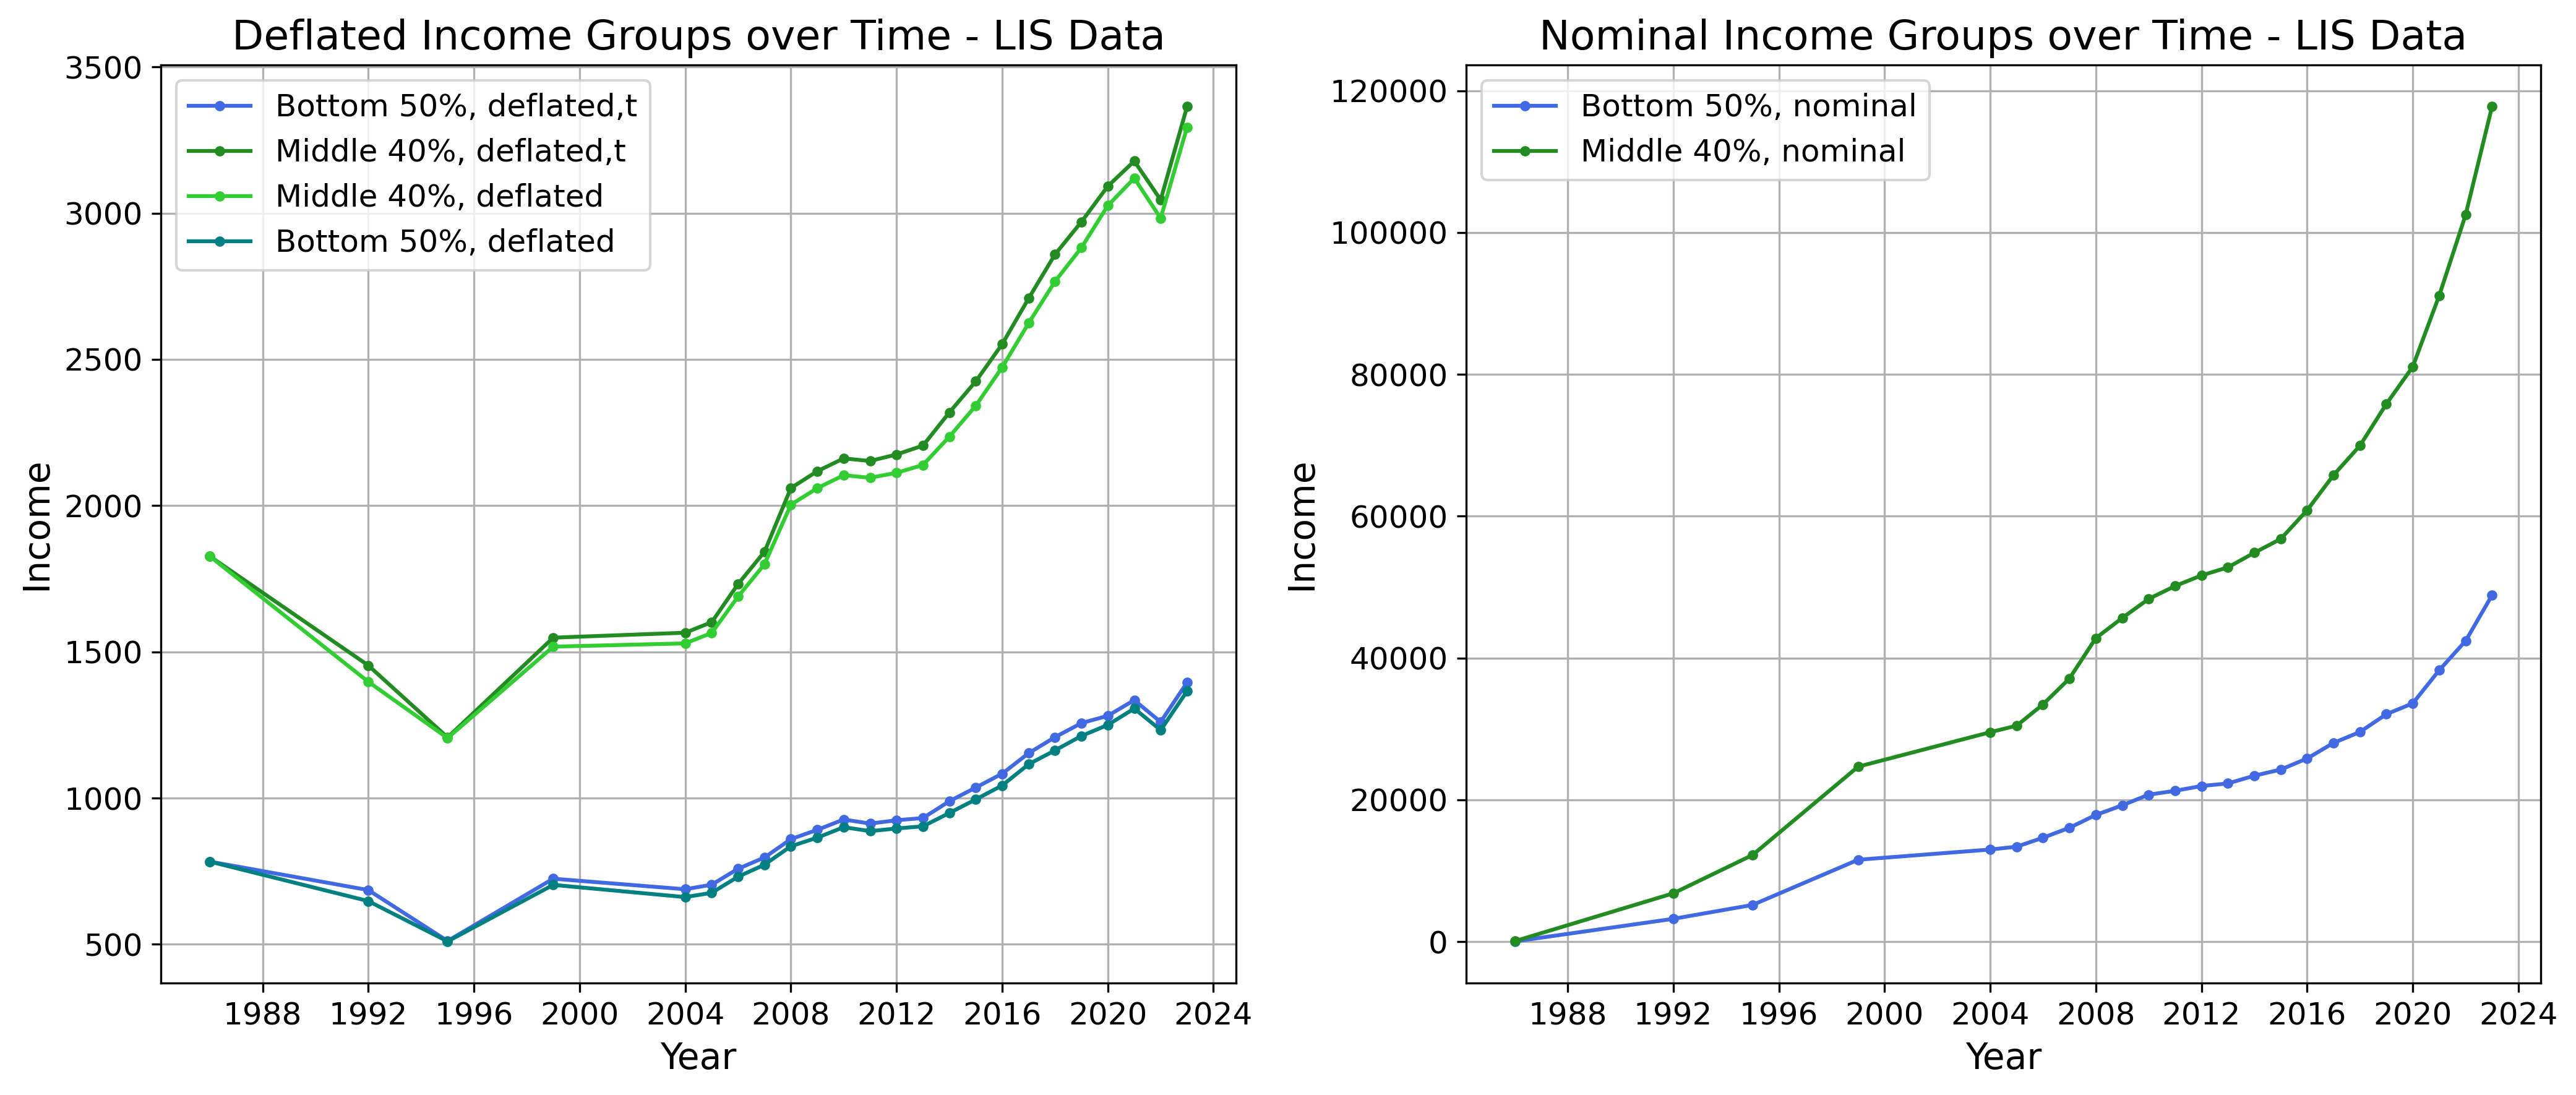

In [ ]:
# two plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Bottom_50_defl'], label='Bottom 50%, deflated,t', color='royalblue', marker='.')
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_P50_90_defl'], label='Middle 40%, deflated,t', color='forestgreen', marker='.')
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hinoncap_P50_90_defl'], label='Middle 40%, deflated', color='limegreen', marker='.')
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hinoncap_Bottom_50_defl'], label='Bottom 50%, deflated', color='teal', marker='.')
ax[1].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Bottom_50'], label='Bottom 50%, nominal', color='royalblue', marker='.')
ax[1].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_P50_90'], label='Middle 40%, nominal', color='forestgreen', marker='.')

ax[0].set_title('Deflated Income Groups over Time - LIS Data')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Income')
ax[1].set_title('Nominal Income Groups over Time - LIS Data')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_3_income_groups_comparison_top40.png', dpi =300)
plt.show()

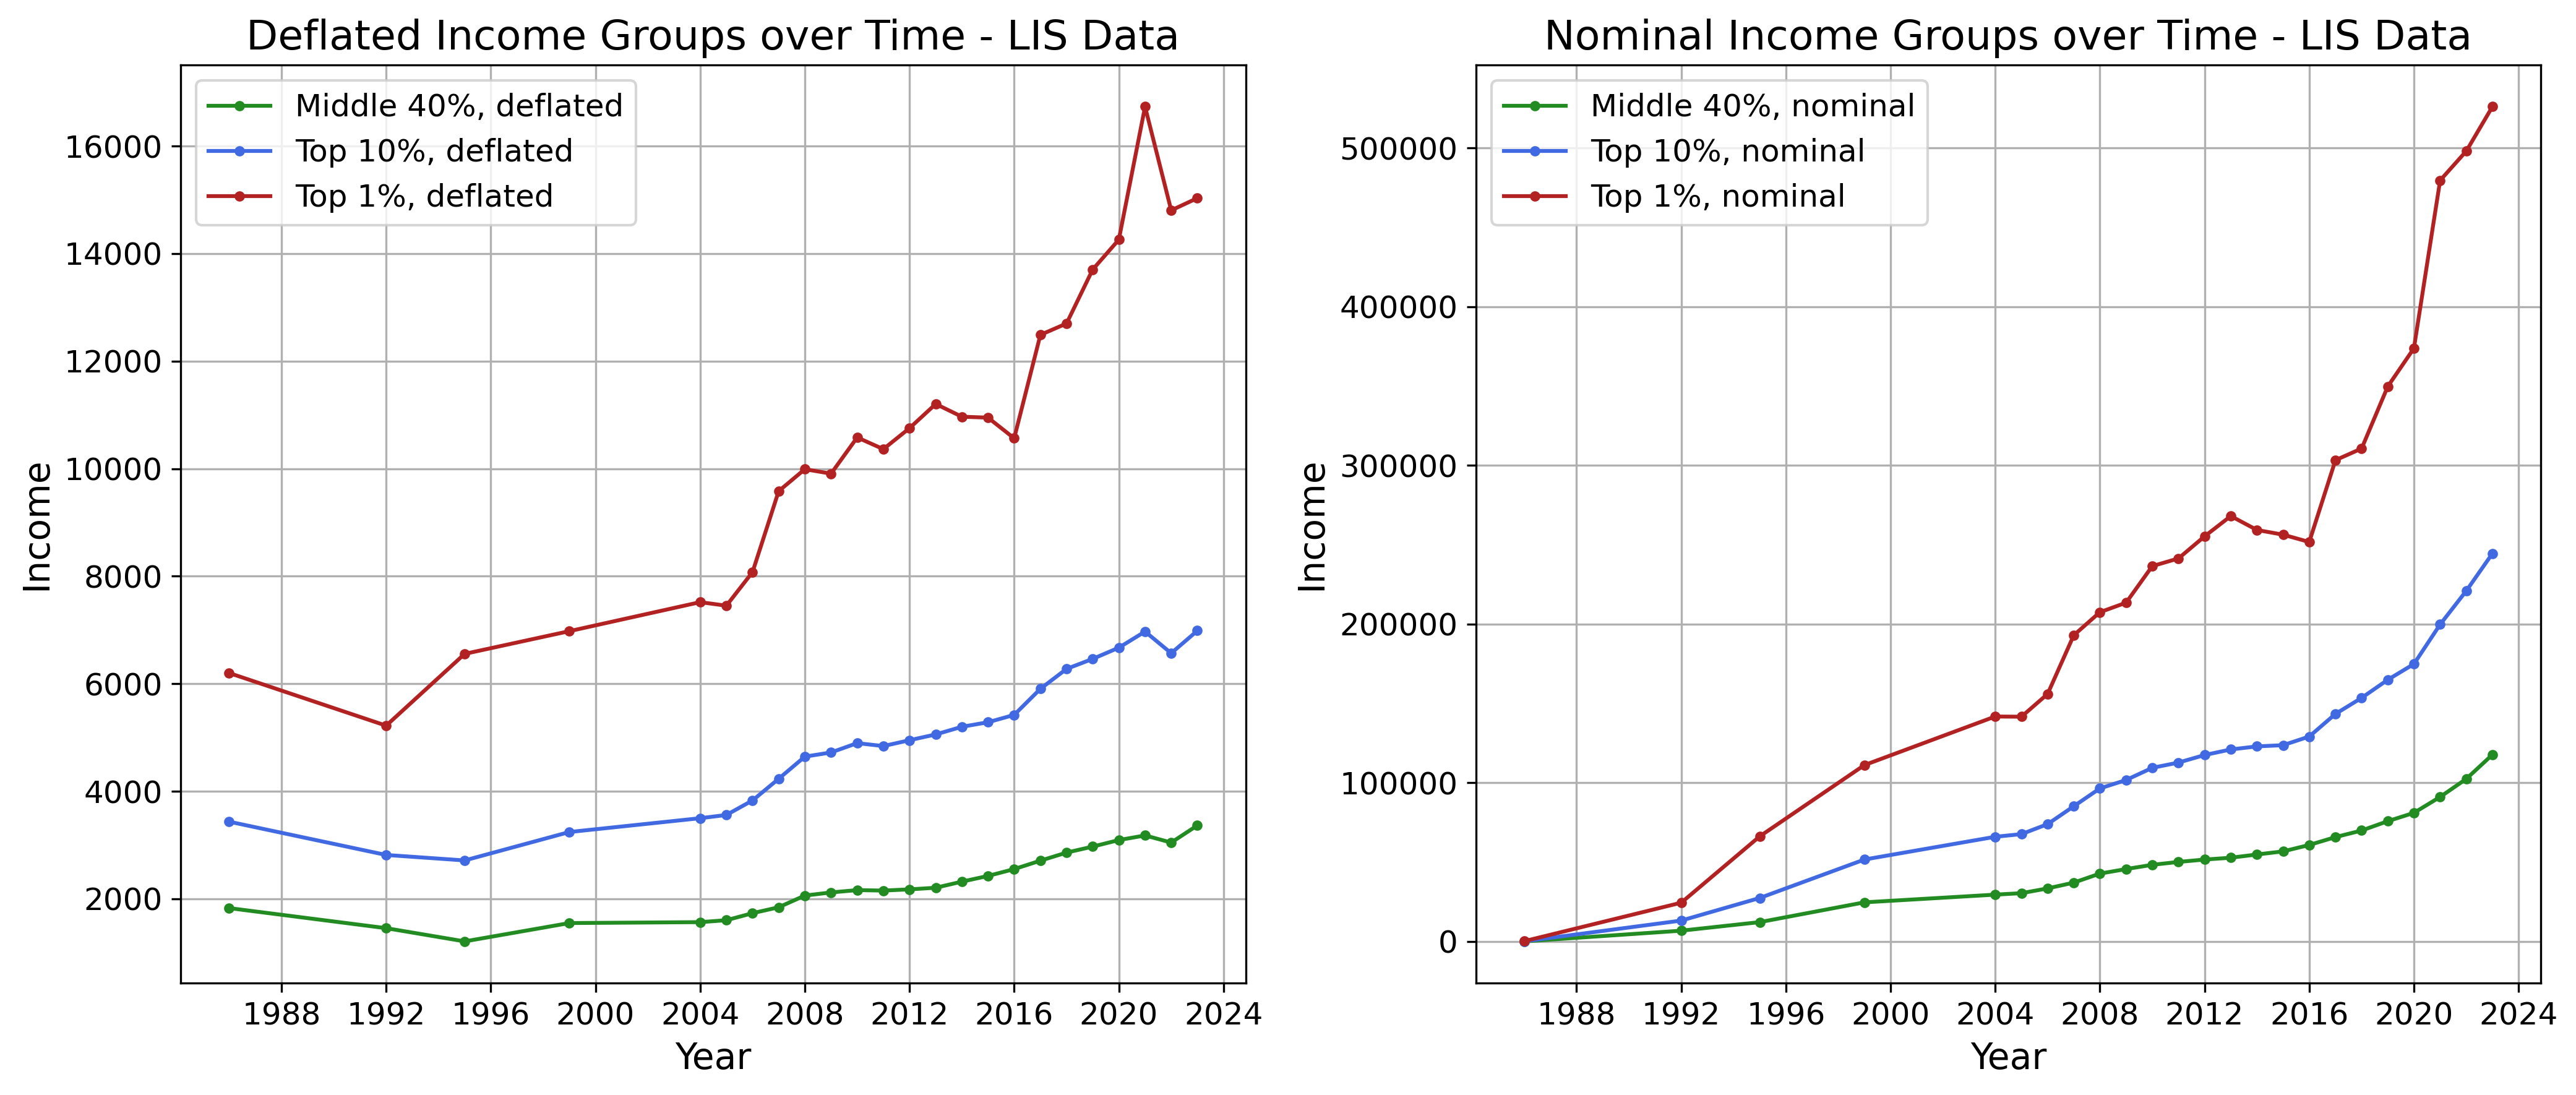

In [ ]:
# Two plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_P50_90_defl'], label='Middle 40%, deflated', color='forestgreen', marker='.')
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Top_10_defl'], label='Top 10%, deflated', color='royalblue', marker='.')
ax[0].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Top_1_defl'], label='Top 1%, deflated', color='firebrick', marker='.')
ax[1].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_P50_90'], label='Middle 40%, nominal', color='forestgreen', marker='.')
ax[1].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Top_10'], label='Top 10%, nominal', color='royalblue', marker='.')
ax[1].plot(incomeh_groups_evolution['year'], incomeh_groups_evolution['hitotal_Top_1'], label='Top 1%, nominal', color='firebrick', marker='.')
ax[0].set_title('Deflated Income Groups over Time - LIS Data')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Income')
ax[1].set_title('Nominal Income Groups over Time - LIS Data')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_4_income_groups_comparison_top40_top10.png', dpi =300)
plt.show()

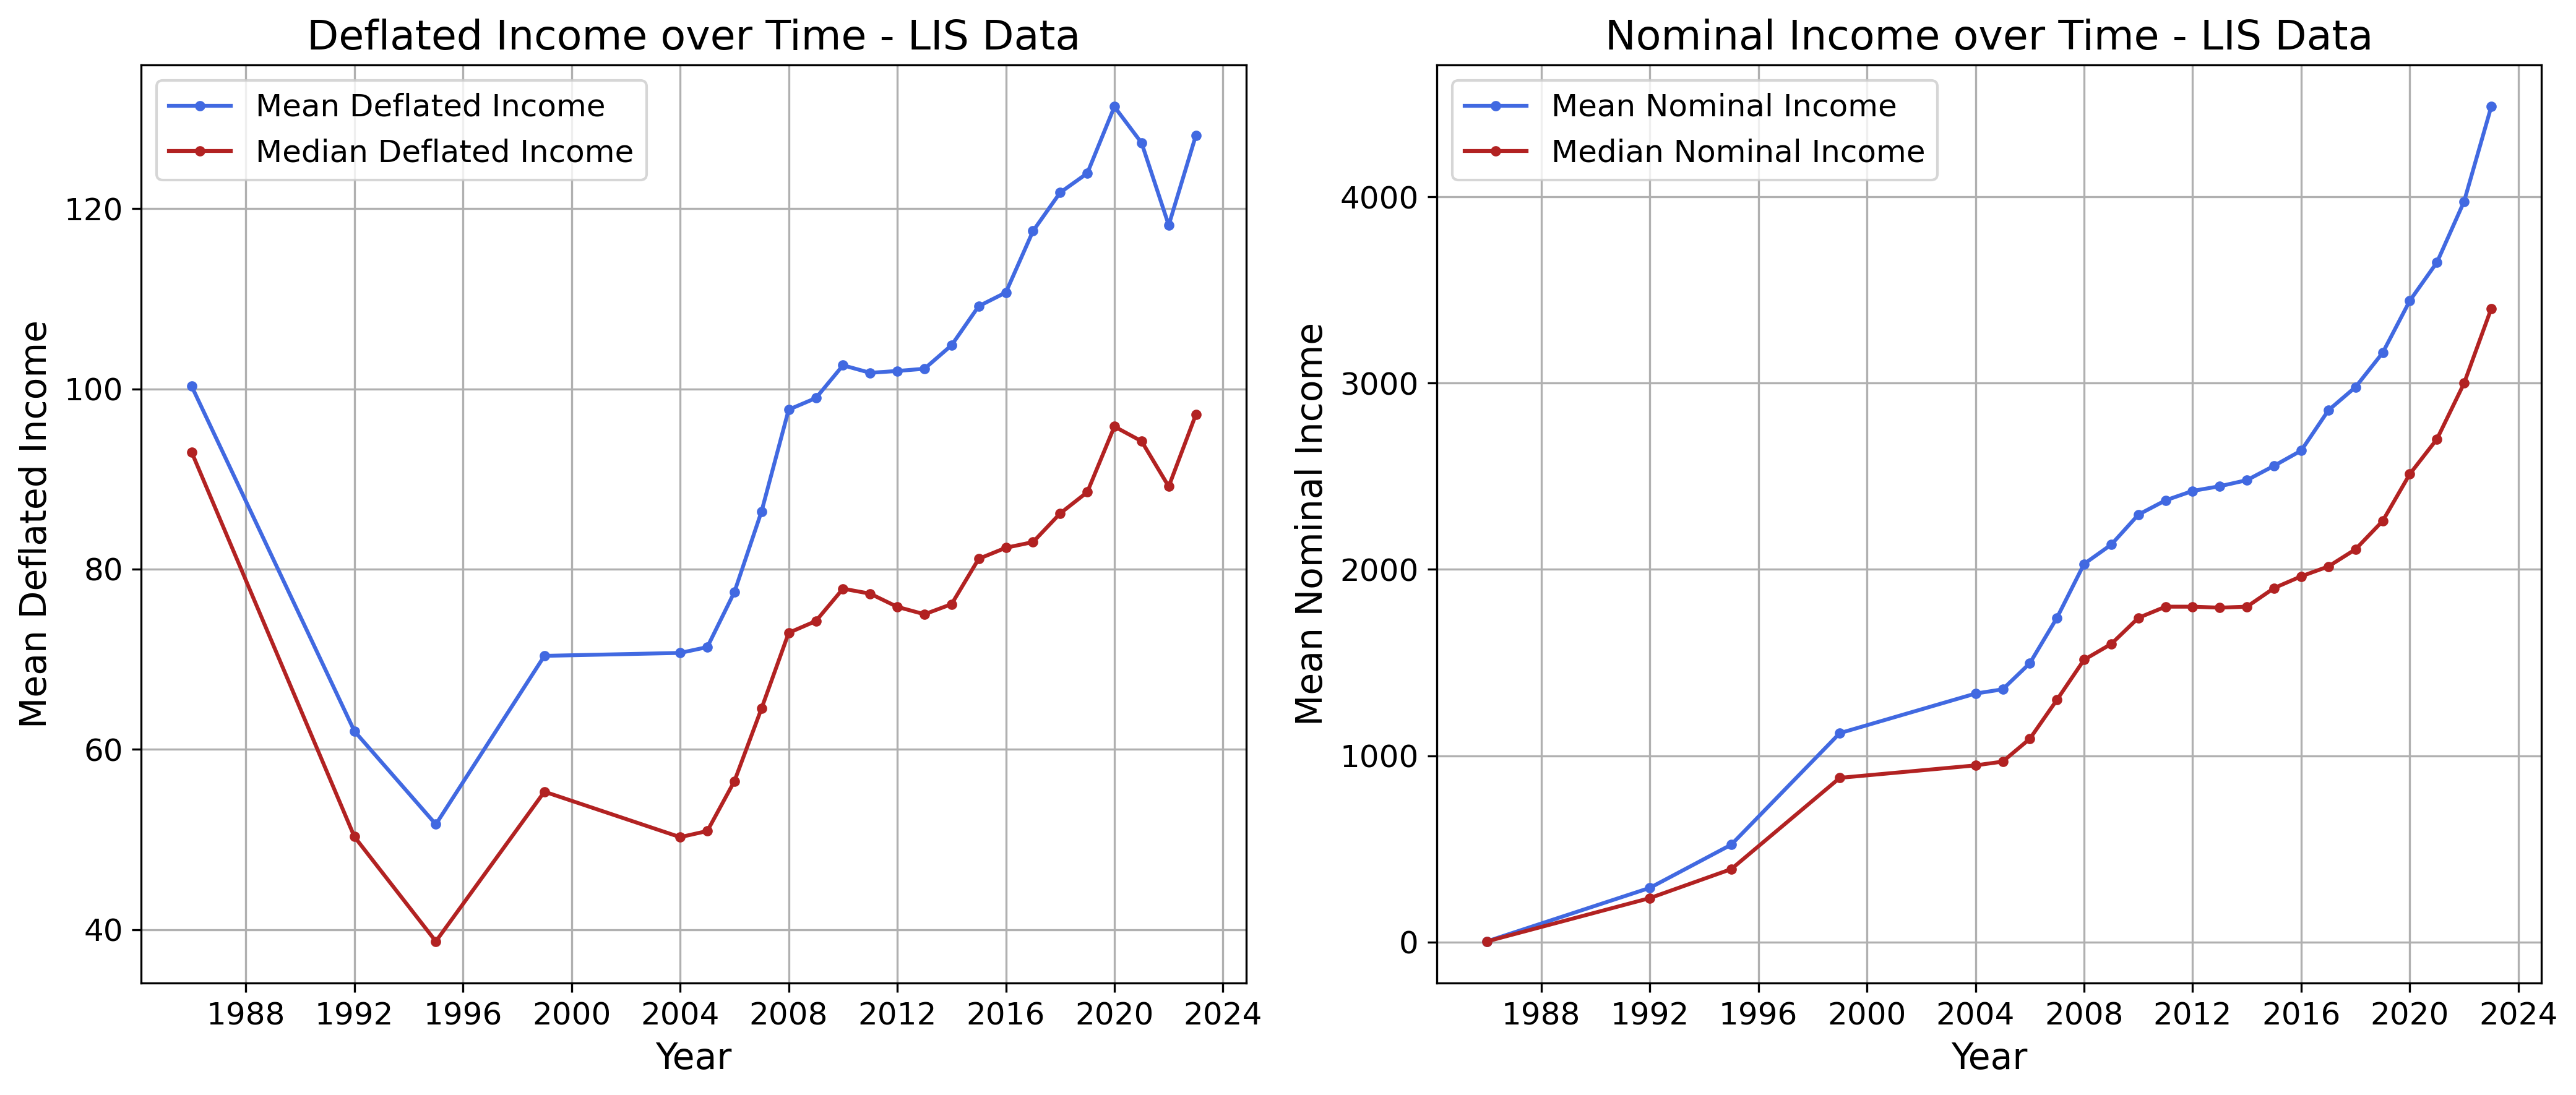

In [ ]:
# plot means over time
import matplotlib.pyplot as plt


# 2 plots side by side
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(incomeh_evolution['year'], incomeh_evolution_delf.values, label='Mean Deflated Income', color='royalblue', marker='.')
ax[0].plot(incomeh_evolution['year'], incomeh_evolution_med_defl.values, label='Median Deflated Income', color='firebrick', marker='.')
ax[0].set_title('Deflated Income over Time - LIS Data')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Mean Deflated Income')
ax[1].plot(incomeh_evolution['year'], incomeh_evolution['mean_incomeh']/12, color='royalblue', label='Mean Nominal Income', marker='.')
ax[1].plot(incomeh_evolution['year'], incomeh_evolution['median_incomeh']/12, label='Median Nominal Income', color='firebrick', marker='.')
ax[1].set_title('Nominal Income over Time - LIS Data')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Mean Nominal Income')
ax[0].legend()
ax[1].legend()
ax[0].grid()
ax[1].grid()
plt.tight_layout()
plt.savefig(lis_plot_root / 'LIS_2_income_comparison.png', dpi =300)
plt.show()